## Python notebook template block B

As of now, you created a new notebook for every study day with the related contents. However, when working on a project in the real life, all your data and code needs to be in one place for the project. Going forward in the block, all of the code that you generate with regard to the final project about NAC and the ILO's should be in this one template. Go back to the code you wrote for the previous weeks, evaluate if it is according to [PEP8](https://peps.python.org/pep-0008/) style guide and adjust where necessary. This template provides you with a natural flow through the steps of a traditional data science project. Do not forget to clearly add comments to your code. If you would like to add more stucture, add extra mark down blocks to explain what you are doing. You are **not** allowed to remove code blocks! All blocks in here need to be filled with code. If you did not write code for a section, leave the code block as is with the pre-filled in comment. Adjust this template to your needs, make sure that all your evidence for all of the ILO's is included.

⚠️Important! Before handing it in, run all of your code. All your cells need to show outputs. This is necessary for grading!⚠️

The ILO's for which you can evidence your code by this notebook are: 

| ILO | Poor | Insufficient | Sufficient | Good | Excellent |
|-----|------|--------------|------------|------|-----------|
| 4.1 | x    | x            | x          | x    | x         |
| 4.2 | x    | x            | x          | x    | x*        |
| 5.0 | x    | x            | x          | x    | x         |
| 7.0 | x    | x            | x          | x    | x         |

4.2 excellent*: If you would like to showcast your graphs using streamlit, you need to hand in a seperate .py file. Evidence accordingly in your learning log.




### Add imports here
When working in .py files, you usually have all your package imports at the top of your code. This makes it easy to get a good overview of the packages that you are using and importing. As of now, we are working in .ipynb, but it is good practice to already start implementing these structures. Add all the imports that you use in all of your code in the code block below. In this way, you do not need to add it in every cell.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import missingno as msno
import seaborn as sns
import requests
import math
import sympy as sp
from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures, StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score, cross_validate, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score, make_scorer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, RandomForestClassifier
from numpy.polynomial.polynomial import Polynomial
from sklearn.feature_selection import SelectKBest
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from xgboost import XGBClassifier, XGBRegressor
from sympy import symbols, sqrt, cbrt, limit, root, oo, sin, cos, tan, diff, cot, ln, E, pi, Eq, solve, expand

### Load the data

After your package imports, you usually load your data. This is what you will be working with and what your code will be based on.

In [2]:
df = pd.read_csv(".//data/all_data.csv")
clean_nacdata = pd.read_csv(".//data/cleaned_Final_NAC_data.csv")


## Data Management and Understanding

### Data Cleansing
In the following section plug in all of your relevant python codes and explanations related to data cleansing. This is related to the poor and insufficient criteria of ILO 4.1 and 4.2.

In [3]:
# Display a previes and some basic info about the dataset
display(df.head())
df.info()

,Unnamed: 0,Player,Team,Team within selected timeframe,Position,Age,Market value,Contract expires,Matches played,Minutes played,...,Prevented goals per 90,Back passes received as GK per 90,Exits per 90,Aerial duels per 90.1,Free kicks per 90,Direct free kicks per 90,"Direct free kicks on target, %",Corners per 90,Penalties taken,"Penalty conversion, %"
0,0,S. Baidoo,Salzburg,Liefering,"RCB, LCB",19.0,1000000,2027-06-30,21,1986,...,NaN,1.45,NaN,NaN,0.00,0.00,0.0,0.00,0,0.0
1,1,M. Seidl,Rapid Wien,Blau-Weiß Linz,"LWF, RWF, AMF",22.0,1000000,2024-06-30,26,2293,...,NaN,0.24,NaN,NaN,0.39,0.31,0.0,0.12,0,0.0
2,2,B. Okoh,Salzburg,Liefering,"LCB, RCB",20.0,1000000,2025-06-30,8,476,...,NaN,1.32,NaN,NaN,0.00,0.00,0.0,0.00,0,0.0
3,3,B. Koumetio,Austria Wien,Austria Wien II,LCB,20.0,600000,2025-06-30,4,389,...,NaN,3.70,NaN,NaN,0.00,0.00,0.0,0.00,0,0.0
4,4,M. Polster,Austria Wien,Austria Wien II,"LB, LAMF",20.0,600000,2025-06-30,5,464,...,NaN,0.39,NaN,NaN,0.00,0.00,0.0,0.00,0,0.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16535 entries, 0 to 16534
Columns: 115 entries, Unnamed: 0 to Penalty conversion, %
dtypes: float64(89), int64(17), object(9)
memory usage: 14.5+ MB


The dataset under analysis comprises detailed information on 16,535 football players, with data organized into 115 columns. Each column represents a specific attribute related to the players, ranging from performance metrics to personal information. The data types within these columns vary: 89 columns contain floating-point numbers (float64), which typically represent continuous numerical values such as average scores or percentages; 17 columns contain integer values (int64), likely representing countable features like the number of goals scored or matches played; and 9 columns contain categorical data (object), which may include textual information such as player names or positions. The dataset's comprehensive nature suggests it can be used for extensive analysis, potentially facilitating performance evaluation, trend identification, and statistical modeling within the realm of football analytics. But for this specific project, we'll use the data to predict the market value.

_____________________________________

The next step after seeing the contents of the data is to deal with the missing values, i.e removing them. but first, visualizing it using missingno python library is useful to get an idea of the missing values in the data.

In [4]:
# Detect the number of missing values per column
missing_values = df.isnull().sum()

# Print the result
print("Number of missing values per column:")
print(missing_values)

Number of missing values per column:
Unnamed: 0                           0
Player                               0
Team                               625
Team within selected timeframe       0
Position                            56
                                  ... 
Direct free kicks per 90          1510
Direct free kicks on target, %    1510
Corners per 90                     232
Penalties taken                      0
Penalty conversion, %                0
Length: 115, dtype: int64


In [5]:
# Visualise the number of missing values as a bar chart
#msno.matrix(df)

The approach to addressing missing values typically varies based on the type of missingness and the characteristics of the data. The bar chart shows that most columns have over 95% of their data available. Notably, the three columns at the top of the chart, "Direct free kicks on target %", "Direct free kicks per 90", and "Free kicks per 90", each have 1510 missing values, which represent around 10% of the entire dataset. To better understand the nature of this missing data, we will investigate the type of missingness by displaying all rows with missing values simultaneously.

In [6]:
# Specify the columns of interest
columns_of_interest = ["Direct free kicks on target, %", "Direct free kicks per 90", "Free kicks per 90"]

# Use boolean indexing to filter rows with missing data in specified columns
rows_with_missing_data = df[df[columns_of_interest].isnull().all(axis=1)]

# Display the resulting DataFrame and basic info about it
display(rows_with_missing_data.head(20))
print(rows_with_missing_data.info())

,Unnamed: 0,Player,Team,Team within selected timeframe,Position,Age,Market value,Contract expires,Matches played,Minutes played,...,Prevented goals per 90,Back passes received as GK per 90,Exits per 90,Aerial duels per 90.1,Free kicks per 90,Direct free kicks per 90,"Direct free kicks on target, %",Corners per 90,Penalties taken,"Penalty conversion, %"
37,37,F. Stolz,St. Pölten,St. Pölten,GK,22.0,300000,2026-06-30,29,2761,...,0.163,0.00,1.66,0.68,NaN,NaN,NaN,0.0,0,0.0
44,44,J. Meierhofer,Grazer AK,Grazer AK,GK,25.0,300000,2024-06-30,28,2690,...,0.039,0.00,1.34,0.33,NaN,NaN,NaN,0.0,0,0.0
46,46,E. Scherf,Amstetten,Amstetten,GK,20.0,300000,2024-06-30,23,2207,...,0.097,0.04,1.43,0.82,NaN,NaN,NaN,0.0,0,0.0
51,51,N. Schmid,Blau-Weiß Linz,Blau-Weiß Linz,GK,26.0,300000,2025-06-30,29,2805,...,-0.133,0.00,1.57,0.29,NaN,NaN,NaN,0.0,0,0.0
55,55,J. Krumrey,Liefering,Liefering,GK,19.0,300000,2027-06-30,26,2459,...,0.181,0.00,1.83,0.55,NaN,NaN,NaN,0.0,0,0.0
66,66,J. Ospelt,FSV Frankfurt,Dornbirn,GK,23.0,250000,2024-06-30,24,2316,...,0.112,0.00,2.41,0.89,NaN,NaN,NaN,0.0,0,0.0
68,68,F. Ehmann,Hartberg,Horn,GK,24.0,250000,NaN,16,1536,...,0.104,0.00,1.70,0.41,NaN,NaN,NaN,0.0,0,0.0
112,112,L. Orgler,Rapid Wien,Rapid Wien II,GK,18.0,250000,2025-06-30,25,2388,...,-0.115,0.00,2.11,0.90,NaN,NaN,NaN,0.0,0,0.0
119,119,S. Conde,Stripfing,Austria Wien II,GK,20.0,225000,2025-05-31,22,2069,...,-0.170,0.00,1.57,0.74,NaN,NaN,NaN,0.0,0,0.0
124,124,C. Giuliani,Kapfenberger SV,Kapfenberger SV,GK,24.0,200000,NaN,20,1933,...,-0.022,0.00,1.91,0.47,NaN,NaN,NaN,0.0,0,0.0


<class 'pandas.core.frame.DataFrame'>
Index: 1510 entries, 37 to 16525
Columns: 115 entries, Unnamed: 0 to Penalty conversion, %
dtypes: float64(89), int64(17), object(9)
memory usage: 1.3+ MB
None


The dataset comprises detailed information about 1,510 football players, indexed from 37 to 16,525. It includes 115 columns, each representing different attributes of the players, ranging from general identifiers to specific performance metrics.
____________

Continuing the examination of the missing data by analyzing the following columns: "Aerial duels per 90.1," "Exits per 90," "Prevented goals per 90," "Prevented goals," "Shots against per 90," and "Conceded goals per 90." Almost all these columns have a consistent number of missing data points, amounting to **15257** rows, except for the "Prevented goals" column, which has two additional missing rows. This missing data accounts for over 90% of our dataset.

Since the missing data exceeds the available data, we'll take a reverse approach compared to our previous method. We'll focus on examining the existing data to infer insights about the missing data. We'll again display all the rows without missing values for each of these columns simultaneously.

In [7]:
# Specify columns of interest
columns_of_interest = ["Aerial duels per 90.1", "Exits per 90", "Prevented goals per 90", "Prevented goals", "Shots against per 90", "Conceded goals per 90"]

# Filter the DataFrame to include only rows without missing values in specified columns
rows_without_missing_data = df[df[columns_of_interest].notna().all(axis=1)]

# Display the resulting DataFrame and basic info about it
display(rows_without_missing_data.head(20))
print(rows_without_missing_data.info())

,Unnamed: 0,Player,Team,Team within selected timeframe,Position,Age,Market value,Contract expires,Matches played,Minutes played,...,Prevented goals per 90,Back passes received as GK per 90,Exits per 90,Aerial duels per 90.1,Free kicks per 90,Direct free kicks per 90,"Direct free kicks on target, %",Corners per 90,Penalties taken,"Penalty conversion, %"
37,37,F. Stolz,St. Pölten,St. Pölten,GK,22.0,300000,2026-06-30,29,2761,...,0.163,0.00,1.66,0.68,NaN,NaN,NaN,0.0,0,0.0
44,44,J. Meierhofer,Grazer AK,Grazer AK,GK,25.0,300000,2024-06-30,28,2690,...,0.039,0.00,1.34,0.33,NaN,NaN,NaN,0.0,0,0.0
46,46,E. Scherf,Amstetten,Amstetten,GK,20.0,300000,2024-06-30,23,2207,...,0.097,0.04,1.43,0.82,NaN,NaN,NaN,0.0,0,0.0
51,51,N. Schmid,Blau-Weiß Linz,Blau-Weiß Linz,GK,26.0,300000,2025-06-30,29,2805,...,-0.133,0.00,1.57,0.29,NaN,NaN,NaN,0.0,0,0.0
55,55,J. Krumrey,Liefering,Liefering,GK,19.0,300000,2027-06-30,26,2459,...,0.181,0.00,1.83,0.55,NaN,NaN,NaN,0.0,0,0.0
66,66,J. Ospelt,FSV Frankfurt,Dornbirn,GK,23.0,250000,2024-06-30,24,2316,...,0.112,0.00,2.41,0.89,NaN,NaN,NaN,0.0,0,0.0
68,68,F. Ehmann,Hartberg,Horn,GK,24.0,250000,NaN,16,1536,...,0.104,0.00,1.70,0.41,NaN,NaN,NaN,0.0,0,0.0
112,112,L. Orgler,Rapid Wien,Rapid Wien II,GK,18.0,250000,2025-06-30,25,2388,...,-0.115,0.00,2.11,0.90,NaN,NaN,NaN,0.0,0,0.0
119,119,S. Conde,Stripfing,Austria Wien II,GK,20.0,225000,2025-05-31,22,2069,...,-0.170,0.00,1.57,0.74,NaN,NaN,NaN,0.0,0,0.0
124,124,C. Giuliani,Kapfenberger SV,Kapfenberger SV,GK,24.0,200000,NaN,20,1933,...,-0.022,0.00,1.91,0.47,NaN,NaN,NaN,0.0,0,0.0


<class 'pandas.core.frame.DataFrame'>
Index: 1278 entries, 37 to 16525
Columns: 115 entries, Unnamed: 0 to Penalty conversion, %
dtypes: float64(89), int64(17), object(9)
memory usage: 1.1+ MB
None


All these columns consistently feature the exact same rows without any missing data, as indicated by the complete display of 1278 out of 1278 rows. Notably, these rows are specific to goalkeepers, marked as "GK," highlighting a strong link to the goalkeeper position and not to others. Consequently, the absence of missing data is not random but specifically pertains to non-goalkeeper positions.

The "Prevented goals" column, which has two additional missing rows compared to the other columns, suggests that these two rows are likely missing at random. Given that these features are likely exclusive to goalkeepers, it makes sense to replace the missing values with 0.

Furthermore, the label "Aerial duels per 90.1" suggests the existence of another column with the same name, "Aerial duels per 90," in the dataset. The original "Aerial duels per 90" column contains over 95% of its data, making the duplicate "Aerial duels per 90.1" column, which has a significant amount of missing data, redundant. Therefore, it is logical to drop the duplicate column.

__________________


To manage missing data in other key features, consider the following approach:

- For columns like "Position," "Age," "Birth country," and "Passport country," which have a few missing entries per player, it is best to **remove the affected rows**.
- Regarding the "Team" column, players who are not currently associated with any team can be labeled as **"Free Agents."**
- **Statistical features with a small percentage of missing data can be imputed with 0,** as this likely pertains to young players from youth teams who have not yet played in matches and thus lack documented statistics, or it could be due to random data omissions.
- In the case of the "Foot" column, a practical solution is to replace the missing values with **"Unknown."**
- Likewise, for the "Contract expires" column, filling in missing data with **"Unknown"** is advisable, since the contract end dates are not critical for the analysis.


In [8]:
# Drop rows with missing values in critical columns
nacdata = df.dropna(subset=["Position", "Age", "Birth country", "Passport country"])

# Impute missing values in the "Team" column with "Free Agent"
nacdata["Team"] = nacdata["Team"].fillna("Free Agent")

# Impute missing values in the "Foot" column with "Unknown"
nacdata["Foot"] = nacdata["Foot"].fillna("unknown")

# Impute missing values in the "Contract expires" column with "Unknown"
nacdata["Contract expires"] = nacdata["Contract expires"].fillna("Unknown")

# Drop the column "Aerial duels per 90.1"
nacdata.drop(columns=["Aerial duels per 90.1"], inplace=True)

# Fill the remaining missing data with 0
nacdata = nacdata.fillna(0)

# Visualising the number of missing values as a bar chart 
#msno.matrix(nacdata)

C:\Users\sally\AppData\Local\Temp\ipykernel_37796\3265593950.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nacdata["Team"] = nacdata["Team"].fillna("Free Agent")
C:\Users\sally\AppData\Local\Temp\ipykernel_37796\3265593950.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nacdata["Foot"] = nacdata["Foot"].fillna("unknown")
C:\Users\sally\AppData\Local\Temp\ipykernel_37796\3265593950.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_

The dataset has been cleansed from the missing data.

_____

Now that the missing values have been dealt with, dealing with the duplicates is the next step in the cleansing process. Duplicates can be present cause curtain players can be present in different teams due to the possibility of players changing teams during the 2022-2023 seaason. To eliminate the duplicates, using a combination of the name, age and team columns to identify the duplicates before eliminating them.

In [9]:
# Drop duplicate rows based on specific columns
nacdata = df.drop_duplicates(subset=["Player", "Age", "Team"])

# Print the info about the preprocessed dataframe  
print(nacdata.info())

<class 'pandas.core.frame.DataFrame'>
Index: 16284 entries, 0 to 16534
Columns: 115 entries, Unnamed: 0 to Penalty conversion, %
dtypes: float64(89), int64(17), object(9)
memory usage: 14.4+ MB
None


After removing the duplicates, there are now 115 columns left with 16284 rows of pre-processed data.

_____________

Considering that our project centers on attackers, the 'Position' column becomes vital for our analysis. Given that many players hold multiple positions and the combinations are numerous, further preprocessing can improve the utility of this column. We will adhere to these guidelines during preprocessing:

- The 'GK' position denotes goalkeepers.
- The 'CB', 'LB', 'RB', 'LCB', 'RCB', 'LWB', and 'RWB' positions pertain to defenders.
- Midfielders are represented by 'CM', 'CDM', 'CAM', 'LM', 'RM', 'LAMF', 'LDM', 'RDM', 'LCM', 'RCM', 'LAM', 'RAM', 'RCMF', 'LCMF', 'AMF', 'RDMF', 'LDMF', 'DMF', and 'RAMF'.
- Attackers are identified by 'LW', 'LWF', 'RW', 'RWF', 'LF', 'RF', 'LS', 'RS', 'ST', and 'CF'.

To simplify the sequences of player positions, we will break them down into individual positions. Based on these individual positions, we will classify each player into a broader, general position category.

In [10]:
def categorize_position(position): 
    if isinstance(position, float): 
        return "Unknown" 
    position = position.split(",")[0].strip() 
    if position == "GK": 
        return "GK" 
    elif position in ["CB", "LB", "RB", "LCB", "RCB", "LWB", "RWB"]: 
        return "DF" 
    elif position in ["CM", "CDM", "CAM", "LM", "RM","LAMF", "LDM", "RDM", "LCM", "RCM", "LAM", "RAM", "RCMF", "LCMF", "AMF", "RDMF", "LDMF", "DMF", "RAMF"]: 
        return "MF" 
    elif position in ["LW", "LWF" ,"RW", "RWF" ,"LF", "RF", "LS", "RS", "ST", "CF"]: 
        return "ATT" 

nacdata["Position category"] = nacdata["Position"].apply(categorize_position)

C:\Users\sally\AppData\Local\Temp\ipykernel_37796\1895408345.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nacdata["Position category"] = nacdata["Position"].apply(categorize_position)


With the players now grouped into four main types based on their positions, handling their roles becomes a much simpler task. The addition of the "Position category" column facilitates the clear segregation of attacking players from others in our data analysis.

________________________

A further exploration into the "Market value" column might also prove advantageous, where players can be grouped into brackets based on their respective market values. Initially, we should ascertain the range of market values among the players.

In [11]:
# Identify maximum and minimum Market value of players
max_market_value = nacdata["Market value"].max()
min_market_value = nacdata["Market value"].min()

# Print the result
print(f"The market value of players ranges from {min_market_value} to {max_market_value}.")

The market value of players ranges from 0 to 60000000.


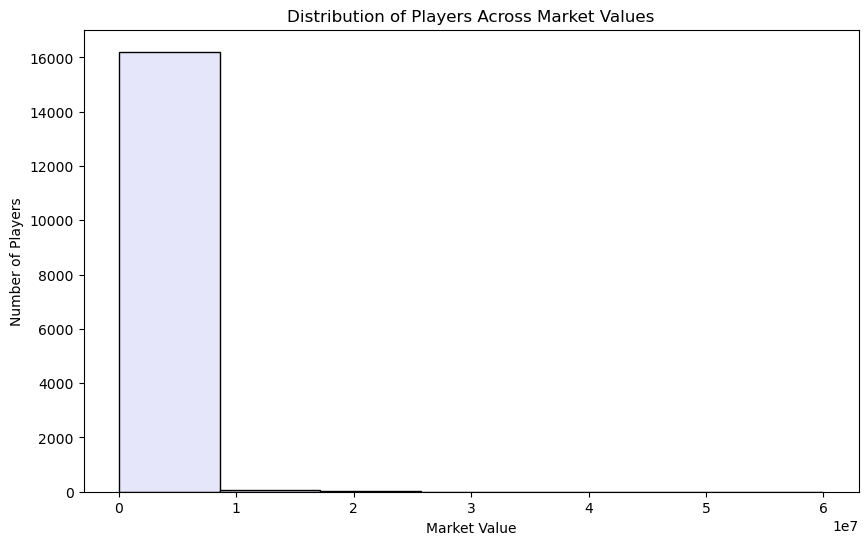

In [12]:
# Plotting the histogram
plt.figure(figsize=(10, 6))
plt.hist(nacdata["Market value"], bins=7, color="Lavender", edgecolor="black")
plt.title("Distribution of Players Across Market Values")
plt.xlabel("Market Value")
plt.ylabel("Number of Players")
plt.show()

The market value ranges from 0 to 60,000,000. To find out each players market value range, the columns need to be devided into 3 catagories. (low, medium and high)

After doing some general research about the average football player market value, and seeing how unevenly distrubuted the dataset is, the data will be split in equal measures to make sure the 3 catagories have a near equal number or rows.

- Low value: Players that have the value of less than 150 Thousand
- Medium Value: Players that have the value of between 150 Thousand and 400 Thousand
- High Value: Players that have the value of higher than 400 Thousand

In [13]:
# Define the bins and labels
bins = [0,150_000, 400_000, float("inf")]
labels = ["Lower Value Bin", "Medium Value Bin", "Higher Value Bin"]

# Create the "Bin" column based on Market Value
nacdata["Bin"] = pd.cut(nacdata["Market value"], bins=bins, labels=labels, right=False)

# Display the updated dataframe
display(nacdata.head())

C:\Users\sally\AppData\Local\Temp\ipykernel_37796\4157938585.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nacdata["Bin"] = pd.cut(nacdata["Market value"], bins=bins, labels=labels, right=False)


,Unnamed: 0,Player,Team,Team within selected timeframe,Position,Age,Market value,Contract expires,Matches played,Minutes played,...,Exits per 90,Aerial duels per 90.1,Free kicks per 90,Direct free kicks per 90,"Direct free kicks on target, %",Corners per 90,Penalties taken,"Penalty conversion, %",Position category,Bin
0,0,S. Baidoo,Salzburg,Liefering,"RCB, LCB",19.0,1000000,2027-06-30,21,1986,...,NaN,NaN,0.00,0.00,0.0,0.00,0,0.0,DF,Higher Value Bin
1,1,M. Seidl,Rapid Wien,Blau-Weiß Linz,"LWF, RWF, AMF",22.0,1000000,2024-06-30,26,2293,...,NaN,NaN,0.39,0.31,0.0,0.12,0,0.0,ATT,Higher Value Bin
2,2,B. Okoh,Salzburg,Liefering,"LCB, RCB",20.0,1000000,2025-06-30,8,476,...,NaN,NaN,0.00,0.00,0.0,0.00,0,0.0,DF,Higher Value Bin
3,3,B. Koumetio,Austria Wien,Austria Wien II,LCB,20.0,600000,2025-06-30,4,389,...,NaN,NaN,0.00,0.00,0.0,0.00,0,0.0,DF,Higher Value Bin
4,4,M. Polster,Austria Wien,Austria Wien II,"LB, LAMF",20.0,600000,2025-06-30,5,464,...,NaN,NaN,0.00,0.00,0.0,0.00,0,0.0,DF,Higher Value Bin


In [14]:
higher_value_players = nacdata[nacdata["Bin"] == "Higher Value Bin"]

# Print some information about these players
print("Players in the Higher Value Bin:")
display(higher_value_players[["Player", "Team", "Market value", "Bin"]].head())
print("Number of Higher Value Players:", len(higher_value_players))

print("\n")

medium_value_players = nacdata[nacdata["Bin"] == "Medium Value Bin"]

# Print some information about these players
print("Players in the Medium Value Bin:")
display(medium_value_players[["Player", "Team", "Market value", "Bin"]].head())
print("Number of Medium Value Players:", len(medium_value_players))

print("\n")

lower_value_players = nacdata[nacdata["Bin"] == "Lower Value Bin"]

# Print some information about these players
print("Players in the Lower Value Bin:")
display(lower_value_players[["Player", "Team", "Market value", "Bin"]].head())
print("Number of Lower Value Players:", len(lower_value_players))

Players in the Higher Value Bin:


,Player,Team,Market value,Bin
0,S. Baidoo,Salzburg,1000000,Higher Value Bin
1,M. Seidl,Rapid Wien,1000000,Higher Value Bin
2,B. Okoh,Salzburg,1000000,Higher Value Bin
3,B. Koumetio,Austria Wien,600000,Higher Value Bin
4,M. Polster,Austria Wien,600000,Higher Value Bin


Number of Higher Value Players: 5102


Players in the Medium Value Bin:


,Player,Team,Market value,Bin
21,M. Baltaxa,Austria Wien,350000,Medium Value Bin
22,M. Pfeifer,Hartberg,350000,Medium Value Bin
23,D. Kreiker,Stripfing,350000,Medium Value Bin
24,L. Hartwig,Bochum,350000,Medium Value Bin
25,M. Tóth,Vasas,350000,Medium Value Bin


Number of Medium Value Players: 6098


Players in the Lower Value Bin:


,Player,Team,Market value,Bin
238,M. Zwickl,Rapid Wien II,125000,Lower Value Bin
239,D. Schütz,St. Pölten,125000,Lower Value Bin
240,N. Zatl,First Vienna,125000,Lower Value Bin
241,Y. Scheidegger,St. Pölten,125000,Lower Value Bin
242,T. Schiestl,Grazer AK,125000,Lower Value Bin


Number of Lower Value Players: 5084


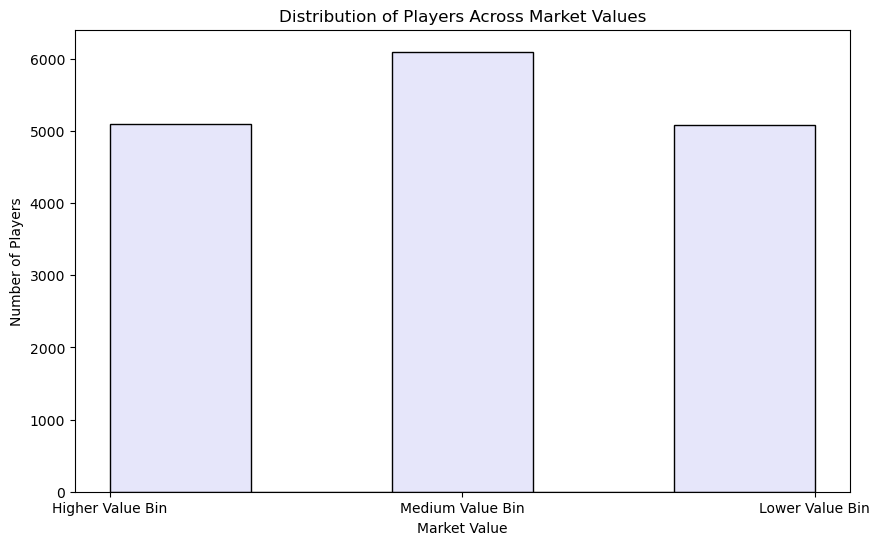

In [15]:
# Plotting the histogram
plt.figure(figsize=(10, 6))
plt.hist(nacdata["Bin"], bins=5, color="Lavender", edgecolor="black")
plt.title("Distribution of Players Across Market Values")
plt.xlabel("Market Value")
plt.ylabel("Number of Players")
plt.show()

As shown in the image above, The data is split alomst evenly between the 3 ranges created for the market value.

____________

To make the data more useable, catagorizing the columns types into either numerical or categorical is beneficial. this is done to make sure if the column is stored in the proper format for further analysis.

In [16]:
# Split columns into numerical and categorical
numerical_columns = nacdata.select_dtypes(include=["int64", "float64"]).columns
categorical_columns = nacdata.select_dtypes(include=["object", "category"]).columns

# Separate numerical and categorical data
numerical_data = nacdata[numerical_columns]
categorical_data = nacdata[categorical_columns]

# Print numerical columns and their data types
print("Numerical Columns:")
for column in numerical_columns:
    print(f"{column}: {nacdata[column].dtype}")

# Print categorical columns and their data types
print("\nCategorical Columns:")
for column in categorical_columns:
    print(f"{column}: {nacdata[column].dtype}")

Numerical Columns:
Unnamed: 0: int64
Age: float64
Market value: int64
Matches played: int64
Minutes played: int64
Goals: int64
xG: float64
Assists: int64
xA: float64
Duels per 90: float64
Duels won, %: float64
Height: int64
Weight: int64
Successful defensive actions per 90: float64
Defensive duels per 90: float64
Defensive duels won, %: float64
Aerial duels per 90: float64
Aerial duels won, %: float64
Sliding tackles per 90: float64
PAdj Sliding tackles: float64
Shots blocked per 90: float64
Interceptions per 90: float64
PAdj Interceptions: float64
Fouls per 90: float64
Yellow cards: int64
Yellow cards per 90: float64
Red cards: int64
Red cards per 90: float64
Successful attacking actions per 90: float64
Goals per 90: float64
Non-penalty goals: int64
Non-penalty goals per 90: float64
xG per 90: float64
Head goals: int64
Head goals per 90: float64
Shots: int64
Shots per 90: float64
Shots on target, %: float64
Goal conversion, %: float64
Assists per 90: float64
Crosses per 90: float64
Ac

After examining the data, it's clear that most columns are correctly formatted. However, there's an interesting case with the "Contract expires" column, which is currently labeled as an object. Since this column contains dates indicating contract expirations, it makes sense to convert it to a date format for consistency.

Before converting, our priority should be handling any 'Unknown' values present in the "Contract expires" column. Once these are resolved, we can proceed with updating the column's data type accordingly.

In [17]:
# Change the "Unknown" values to 0
nacdata["Contract expires"] = nacdata["Contract expires"].replace("Unknown", 0)

# Convert the datatype into date format
nacdata["Contract expires"] = pd.to_datetime(nacdata["Contract expires"], errors="coerce")

C:\Users\sally\AppData\Local\Temp\ipykernel_37796\2208976303.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nacdata["Contract expires"] = nacdata["Contract expires"].replace("Unknown", 0)
C:\Users\sally\AppData\Local\Temp\ipykernel_37796\2208976303.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nacdata["Contract expires"] = pd.to_datetime(nacdata["Contract expires"], errors="coerce")


Upon reviewing, we've made essential adjustments to eliminate missing data and duplicates, ensuring the dataset is well-prepared for the EDA process. The next step involves additional preprocessing before proceeding with our machine learning model.

Now that we've finished preprocessing and cleaning the data, we're prepared to store the revised dataset in a new file.

In [18]:
# Providing a path for a CSV NAC Data file
file_path = "/Users/sally/Desktop/School/2023-24b-fai1-adsai-SallyIbrahim211066/data/Final_NAC_Data.csv"

# Saving the combined DataFrame into a CSV file
nacdata.to_csv(file_path, index=False)

print(f"The combined data has been saved to {file_path}")

The combined data has been saved to /Users/sally/Desktop/School/2023-24b-fai1-adsai-SallyIbrahim211066/data/Final_NAC_Data.csv


### Exploratory Data Analysis

Include all exploratory Data Analysis questions you studied in this section. This is related to the sufficient and good criteria of ILO 4.1 and 4.2. 

In [19]:
nacdata.describe()

,Unnamed: 0,Age,Market value,Contract expires,Matches played,Minutes played,Goals,xG,Assists,xA,...,Prevented goals per 90,Back passes received as GK per 90,Exits per 90,Aerial duels per 90.1,Free kicks per 90,Direct free kicks per 90,"Direct free kicks on target, %",Corners per 90,Penalties taken,"Penalty conversion, %"
count,16284.000000,16276.000000,1.628400e+04,9291,16284.000000,16284.000000,16284.000000,16284.000000,16284.000000,16284.000000,...,1266.000000,16053.000000,1266.000000,1266.000000,14787.000000,14787.000000,14787.000000,16053.000000,16284.000000,16284.000000
mean,8252.280398,25.245146,5.059515e+05,2025-01-12 12:16:58.275750912,20.982744,1494.720339,1.808339,1.901707,1.061410,1.124016,...,-0.050984,0.588210,1.488752,0.439968,0.235633,0.043778,6.809999,0.398763,0.211742,7.646751
min,0.000000,15.000000,0.000000e+00,2023-06-30 00:00:00,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,-2.623000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4126.750000,22.000000,1.000000e+05,2024-06-30 00:00:00,14.000000,759.000000,0.000000,0.290000,0.000000,0.130000,...,-0.173000,0.000000,1.100000,0.260000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,8246.500000,25.000000,2.250000e+05,2024-06-30 00:00:00,21.000000,1402.000000,1.000000,1.020000,0.000000,0.630000,...,-0.031000,0.290000,1.440000,0.400000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,12382.250000,29.000000,4.500000e+05,2025-06-30 00:00:00,28.000000,2129.000000,2.000000,2.420000,2.000000,1.570000,...,0.109000,0.880000,1.810000,0.580000,0.200000,0.000000,0.000000,0.270000,0.000000,0.000000
max,16534.000000,42.000000,6.000000e+07,2032-06-30 00:00:00,45.000000,4491.000000,30.000000,23.230000,22.000000,21.510000,...,1.488000,7.170000,4.790000,2.080000,4.470000,1.230000,100.000000,8.140000,14.000000,100.000000
std,4769.861806,4.641507,1.403196e+06,NaN,9.180959,863.774840,2.851359,2.555515,1.618966,1.433942,...,0.276212,0.745128,0.556715,0.268527,0.491338,0.109716,20.587667,0.859080,0.782646,25.567432


In the table above, the mean, count, median, minimum value and maximum value as well as the standard devitation are shown. It also shows the values of the frist and third quartiles. 
__________

Next on the EDA is examining the catagorical variables.

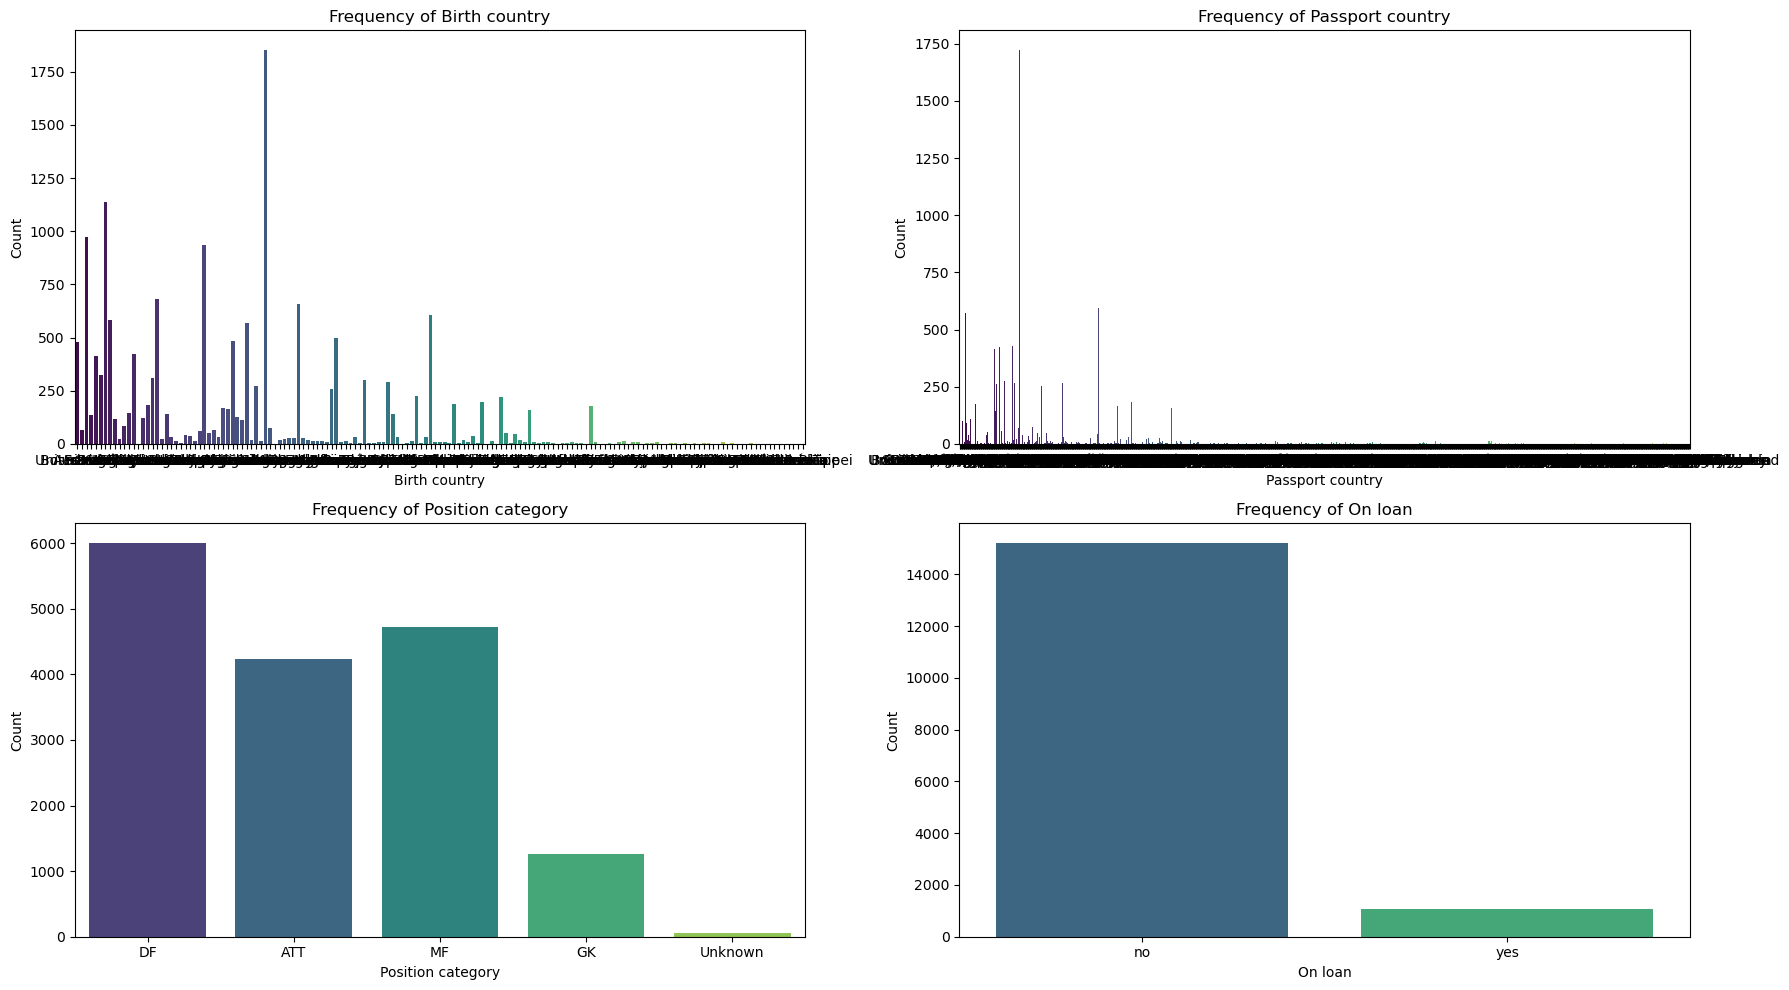

In [20]:
# Select only specific categorical columns
selected_categorical_columns = ["Birth country", "Passport country", "Position category", "On loan"]

# Set up subplots with the calculated number of rows and 2 columns
num_rows = 2
fig, axes = plt.subplots(nrows=num_rows, ncols=2, figsize=(18, 5 * num_rows))

# Plot bar charts for selected categorical columns
for i, column in enumerate(selected_categorical_columns):
    row_index = i // 2
    col_index = i % 2
    sns.countplot(x=column, data=nacdata, ax=axes[row_index, col_index], palette="viridis")
    axes[row_index, col_index].set_title(f"Frequency of {column}")
    axes[row_index, col_index].set_xlabel(column)
    axes[row_index, col_index].set_ylabel("Count")

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()


In [21]:
# Calculate the number of different teams
team_counts = nacdata["Team"].value_counts()
num_teams = len(team_counts)
print("Number of different teams:", num_teams)

# Calculate the number of different passport countries
passport_country_counts = nacdata["Passport country"].value_counts()
num_passport_countries = len(passport_country_counts)
print("Number of different passport countries:", num_passport_countries)

# Calculate the number of different birth countries
birth_country_counts = nacdata["Birth country"].value_counts()
num_birth_countries = len(birth_country_counts)
print("Number of different birth countries:", num_birth_countries)

Number of different teams: 1689
Number of different passport countries: 1118
Number of different birth countries: 155


The observations from the graph are:

- About 1000 players are on loan.
- The position with the most numbers of players is the defender (approx. 6000), then the mid fielder (approx. 5000), then the attacker (approx. 4000), and the lowest is the goal keeper (approx. 1500).
- There are 1689 teams in the dataset.
- There are 1118 recorded passport countries and 155 recorded birth countries.

________________

Next, is answering some general EDA questions, which are:

1. What is the average age in the dataset? 
2. What teams have the highest/lowest market value respectively?
3. Is there a correlation between the player's age and market value?
4. which birth country has the highest number of enteries in the dataset?
5. Is there a correlation between the player's height/weight and their goals?
6. What is the general distribution of yellow cards and red cards between different position?


#### 1. What is the average age of players in the dataset?

In [22]:
# Calculate the average age
average_age = nacdata["Age"].mean()

# Print the result
print(f"The average age is {average_age:.2f} years.")

The average age is 25.25 years.


#### 2. Which team has the highest market value on average?

In [23]:
# Calculate the average market value by team
average_market_value_by_team = nacdata.groupby("Team")["Market value"].mean()

# Find the team with the highest average market value
team_highest_avg_market_value = average_market_value_by_team.idxmax()
highest_avg_market_value = int(average_market_value_by_team.max())

# Find the team with the highest average market value
team_lowest_avg_market_value = average_market_value_by_team.idxmin()
lowest_avg_market_value = int(average_market_value_by_team.min())

# Print the result
print(f"The team with the highest average market value is {team_highest_avg_market_value} with an average market value of {highest_avg_market_value}.")
print(f"The team with the lowest average market value is {team_lowest_avg_market_value} with an average market value of {lowest_avg_market_value}.")

The team with the highest average market value is Liverpool with an average market value of 60000000.
The team with the lowest average market value is AB with an average market value of 0.


#### 3. Is there a correlation between the player's age and market value?

In [24]:
# Calculate the correlation coefficient between the market value and age of players
correlation_coefficient = nacdata["Age"].corr(nacdata["Market value"])

# Print the correlation coefficient
print(f"The market value of players correlates with their age by a correlation coefficient of {correlation_coefficient}.")

The market value of players correlates with their age by a correlation coefficient of 0.008778471240869435.


Considering that the correlation coefficient is at 0.0087, it is safe to conclude that there is no correlation between the age and market value of the players

#### 4. which birth country has the highest number of enteries in the dataset?


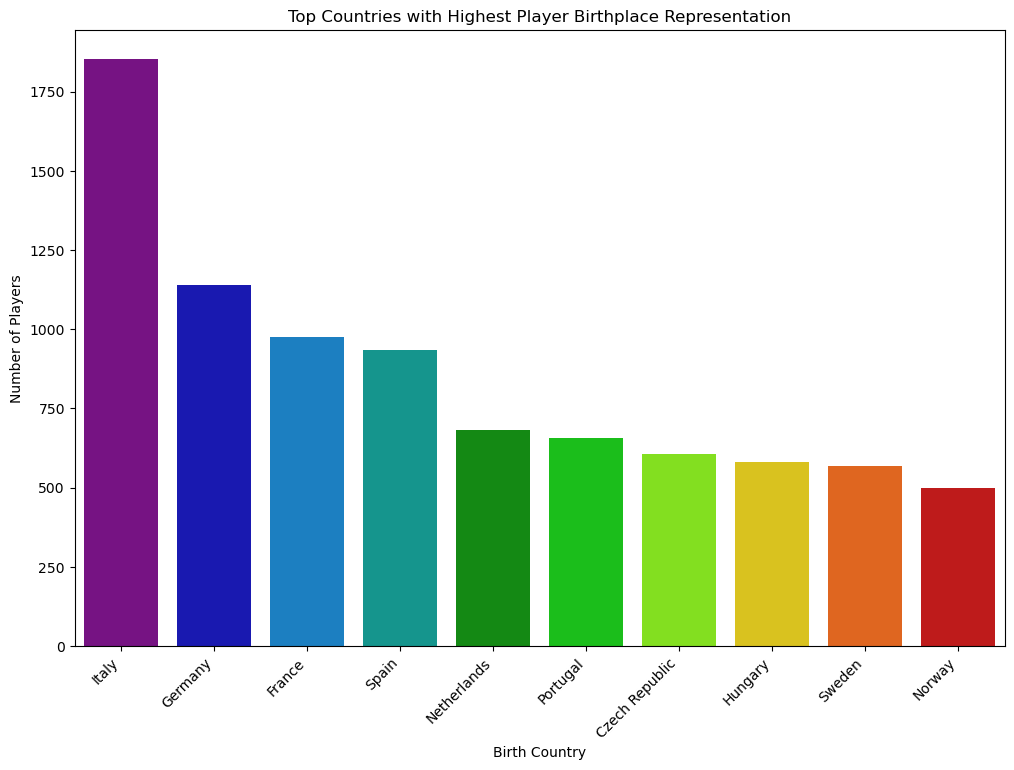

In [25]:
# Calculate the count of players for each birth country
birth_country_counts = nacdata["Birth country"].value_counts()

# Select the top 10 countries with the highest representation
top_countries = birth_country_counts.head(10)

# Create a bar chart
plt.figure(figsize=(12, 8))
sns.barplot(x=top_countries.index, y=top_countries.values, palette="nipy_spectral")
plt.title("Top Countries with Highest Player Birthplace Representation")
plt.xlabel("Birth Country")
plt.ylabel("Number of Players")
plt.xticks(rotation=45, ha="right")

# Show the plot
plt.show()

Italy has the highest representation in the birthplace catagory of it's players in the dataset, which has almost a 2000 enteries.

#### 5. Is there a correlation between the player's height/weight and their goals?

Correlation coefficient between Height and Goals: 0.07
Correlation coefficient between Weight and Goals: 0.07
Correlation coefficient between Weight and Height: 0.83


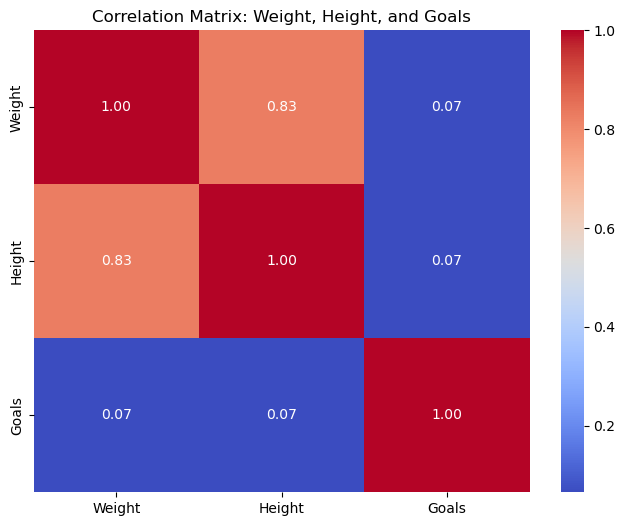

In [26]:
# Correlation between Height and Goals
correlation_height_goals = nacdata["Height"].corr(nacdata["Goals"])
print(f"Correlation coefficient between Height and Goals: {correlation_height_goals:.2f}")

# Correlation between Weight and Goals
correlation_weight_goals = nacdata["Weight"].corr(nacdata["Goals"])
print(f"Correlation coefficient between Weight and Goals: {correlation_weight_goals:.2f}")

# Correlation between Weight and Height
correlation_weight_height = nacdata["Weight"].corr(nacdata["Height"])
print(f"Correlation coefficient between Weight and Height: {correlation_weight_height:.2f}")

# Correlation between Weight, Height, and Goals
correlation_matrix_weight_height_goals = nacdata[["Weight", "Height", "Goals"]].corr()
# Display correlation matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix_weight_height_goals, annot=True, cmap="coolwarm", fmt=".2f", annot_kws={"size": 10})
plt.title("Correlation Matrix: Weight, Height, and Goals")
plt.show()

As expected, the correlation between the height and weight of the players does have a high correlation at 0.83. while the correlarion between the height/weight and the goals is at 0.07, which indicates that there is no correlation.

#### 6. What is the general distribution of yellow cards and red cards between different position?

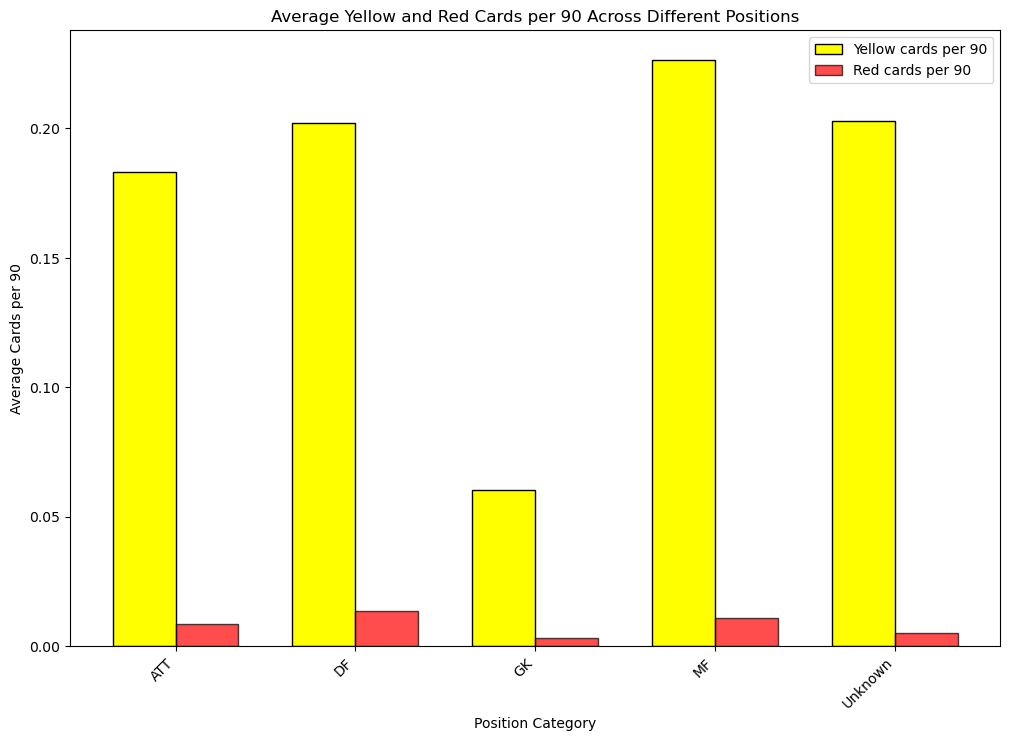

In [27]:
# Filter data for relevant columns
cards_data = nacdata[["Position category", "Yellow cards per 90", "Red cards per 90"]]

# Group by position category and calculate the mean
average_cards_by_position = cards_data.groupby("Position category").mean().reset_index()

# Plotting the bar chart
plt.figure(figsize=(12, 8))

# Bar width for better separation
bar_width = 0.35
indices = np.arange(len(average_cards_by_position))

# Plotting yellow cards
plt.bar(indices, average_cards_by_position["Yellow cards per 90"],
        width=bar_width, label="Yellow cards per 90", color="yellow", edgecolor="black")

# Plotting red cards next to yellow cards
plt.bar(indices + bar_width, average_cards_by_position["Red cards per 90"],
        width=bar_width, label="Red cards per 90", color="red", alpha=0.7, edgecolor="black")

# Set up labels and title
plt.title("Average Yellow and Red Cards per 90 Across Different Positions")
plt.xlabel("Position Category")
plt.ylabel("Average Cards per 90")
plt.legend()

# Adjust x-axis ticks and labels
plt.xticks(indices + bar_width / 2, average_cards_by_position["Position category"])

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha="right")

# Show the plot
plt.show()

The distribution of yellow and red cards among players in different positions varies significantly. Yellow cards are issued far more frequently than red cards. Among all positions, goalkeepers receive the fewest yellow and red cards. Midfielders are the most frequent recipients of yellow cards, while defenders accumulate the highest number of red cards during matches.

___________________

Next is an Overall correlation matrix to get a bigger overview of the columns with the highest correlations

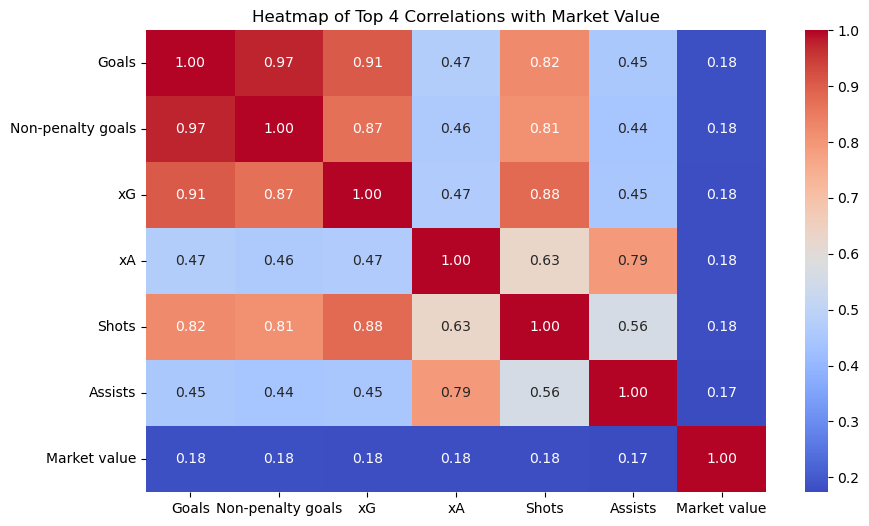

In [28]:
# Calculating the correlation matrix
# Drop non-numeric columns from the dataframe
numeric_columns = nacdata.select_dtypes(include=[np.number]).columns
nacdata_numeric = nacdata[numeric_columns]

# Calculate the correlation matrix
correlation_matrix = nacdata_numeric.corr()

# Getting the correlation of all features with 'Market value'
correlation_with_target = correlation_matrix['Market value'].sort_values(ascending=False)

# Dropping the target variable 'Market value' itself from the correlation series
correlation_with_target = correlation_with_target.drop(labels=['Market value'])

# Selecting features with a significant correlation (here, an arbitrary threshold like 0.1 is chosen)
significant_correlation_threshold = 0.2
significant_features = correlation_with_target[abs(correlation_with_target) > significant_correlation_threshold].index.tolist()

significant_features, len(significant_features)
# Limiting to the top 6features with the highest absolute correlation values
top_features = correlation_with_target.abs().nlargest(6).index.tolist()

# Creating a heatmap for these top correlations
plt.figure(figsize=(10, 6))
sns.heatmap(nacdata[top_features + ['Market value']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap of Top 4 Correlations with Market Value')
plt.show()

### Visualizations

Include all the visualizations you made in this section. This is related to the excellent criteria of ILO 4.2. Use the blocks below to enter the code for graphs you created with matplotlib (or seaborn, bokeh, or another visualization package). 

❗ If you would like to showcast your visualizations using streamlit, you need to hand in a seperate .py file for this. It is not possible to run streamlit code from a python notebook. Please note down below if you do so.

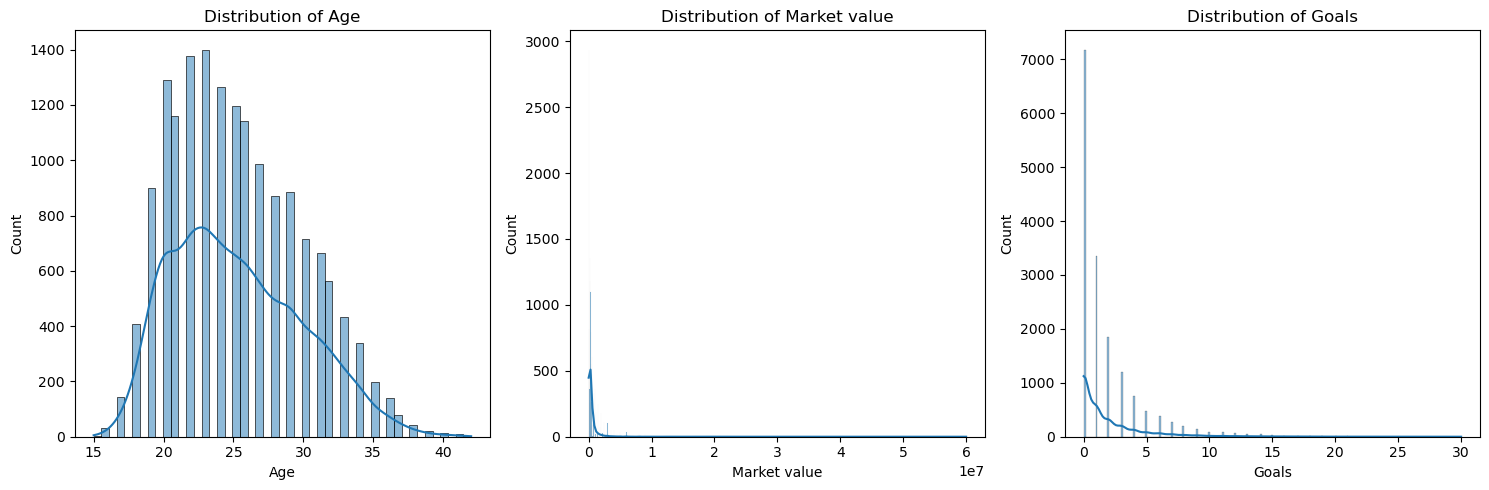

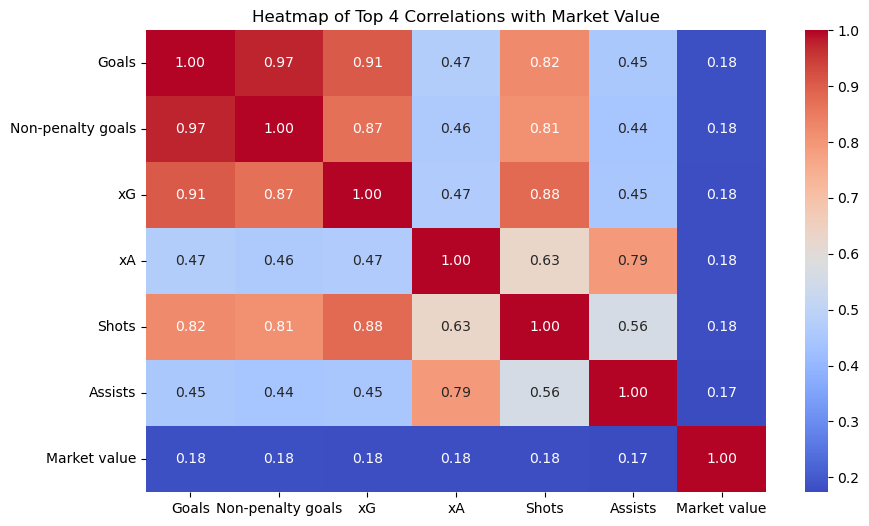

In [29]:
# Setting up the figure for distribution plots
plt.figure(figsize=(15, 5))

# Plotting distributions for 'Age', 'Market value', and 'Goals'
for i, column in enumerate(['Age', 'Market value', 'Goals'], 1):
    plt.subplot(1, 3, i)
    sns.histplot(nacdata[column], kde=True)
    plt.title(f'Distribution of {column}')

plt.tight_layout()
plt.show()

# Creating a heatmap for these top correlations
plt.figure(figsize=(10, 6))
sns.heatmap(nacdata[top_features + ['Market value']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap of Top 4 Correlations with Market Value')
plt.show()

### Database and ETL

Include all the python code and explanations on your RESTful API and database operations in this section. This is related to the excellent criteria of ILO 4.1.

❗ These code you cannot showcast using the NAC data. Use the data provided for the homework and datalab preperation of these modules.

In [30]:
# Get the API KEY and determine your endpoint
API_KEY = "y4EgYq6sqZ8td54VucmhdbMp24th4b6ps4hSF33r"
ENDPOINT = "https://api.giphy.com/v1/gifs/trending"


# Set paramaters 
params = {"api_key": API_KEY, "limit": 3, "rating": "g"}
response = requests.get(ENDPOINT, params=params).json()
for gif in response["data"]:
    title = gif["title"]
    trending_date = gif["trending_datetime"]
    url = gif["url"]
    print(f"{title} | {trending_date}\n{url}\n")

# New endpoint
endpoint1 = "https://api.giphy.com/v1/gifs/search"

# Get a New Searchterm
search_term = "shrug"
params = {"api_key": API_KEY, "limit": 1, "q": search_term, "rating": "g"}
response = requests.get(endpoint1, params=params).json()
for gif in response["data"]:
    title = gif["title"]
    url = gif["url"]
    print(f"{title} | {url}")

query = "moby dick"
endpoint2 = "https://www.googleapis.com/books/v1/volumes"

params = {"q": query, "maxResults": 3}
response = requests.get(endpoint2, params=params).json()
for book in response["items"]:
    volume = book["volumeInfo"]
    title = volume["title"]
    published = volume["publishedDate"]
    description = volume["description"]
    print(f"{title} ({published})\n{description}\n")

Moby Dick (1892)
A literary classic that wasn't recognized for its merits until decades after its publication, Herman Melville's Moby-Dick tells the tale of a whaling ship and its crew, who are carried progressively further out to sea by the fiery Captain Ahab. Obsessed with killing the massive whale, which had previously bitten off Ahab's leg, the seasoned seafarer steers his ship to confront the creature, while the rest of the shipmates, including the young narrator, Ishmael, and the harpoon expert, Queequeg, must contend with their increasingly dire journey. The book invariably lands on any short list of the greatest American novels.

Moby-Dick (2004)
Looking for adventure and a new life, Ishmael, the story's narrator, decides to find work on a whaling boat. On arriving at the Massachusetts harbour to begin his search, the only bed available is already half occupied by a "cannibal" named Queequeg. Although Queequeg has limited English, a friendship forms and the two men sign up for 

### Step-by-Step Explanation of the Code

- **Set API Key and Endpoint for Trending GIFs**:
  - `API_KEY` is assigned the Giphy API key.
  - `ENDPOINT` is set to Giphy's trending GIFs endpoint.

- **Define Parameters and Make GET Request**:
  - Parameters (`params`) are set, including the API key, a limit of 3 GIFs, and a rating of "g" (suitable for general audiences).
  - A `GET` request is made to the Giphy trending endpoint using these parameters.
  - The response is stored in JSON format.

- **Loop Through and Print Trending GIF Data**:
  - For each GIF in the response, its title, trending date, and URL are extracted.
  - The information is printed in a formatted string showing the GIF title, trending date, and URL.

- **Set New Endpoint for Searching GIFs**:
  - A new endpoint `endpoint1` is defined for searching GIFs.

- **Define Search Term and Parameters for Searching GIFs**:
  - A new search term (`search_term = "shrug"`) is defined.
  - Parameters for the search request include the API key, a limit of 1 GIF, the search term (`q`), and a rating of "g".
  - A `GET` request is made to the Giphy search endpoint using these parameters.
  - The response is stored in JSON format.

- **Loop Through and Print Search Results for GIF**:
  - For each GIF in the search results, the title and URL are extracted.
  - The information is printed in a formatted string showing the GIF title and URL.

- **Define a Query for Book Search**:
  - The query `query = "moby dick"` is defined to search for books related to "Moby Dick".

- **Set Endpoint for Google Books API**:
  - `endpoint2` is defined as the endpoint for searching books in the Google Books API.

- **Define Parameters for Book Search**:
  - Parameters for the request include the query (`q = "moby dick"`) and the maximum number of results (`maxResults = 3`).
  - A `GET` request is made to the Google Books API using these parameters.
  - The response is stored in JSON format.

- **Loop Through and Print Book Search Results**:
  - For each book in the search results, the title, publication date, and description are extracted.
  - The information is printed in a formatted string showing the book title, publication date, and description.


In [31]:
import sqlite3

def create_table(cursor):
    # Create a table if it doesn't exist
    cursor.execute('''
        CREATE TABLE IF NOT EXISTS users (
            id INTEGER PRIMARY KEY,
            name TEXT NOT NULL,
            age INTEGER NOT NULL
        )
    ''')

def add_user(cursor, name, age):
    # Insert a new user into the table
    cursor.execute('INSERT INTO users (name, age) VALUES (?, ?)', (name, age))

def delete_user(cursor, name):
    # Delete a user from the table
    cursor.execute('DELETE FROM users WHERE name = ?', (name,))

def main():
    # Connect to the SQLite database (or create a new one if it doesn't exist)
    conn = sqlite3.connect('Week3DataPrep3_DB_211066.db')

    # Create a cursor object to interact with the database
    cursor = conn.cursor()

    # Create the table if it doesn't exist
    create_table(cursor)

    # Ask the user if they want to add or delete
    action = input("Do you want to add or delete a person? ").lower()

    if action == 'add':
        # Get user input for name and age
        name = input("Enter the name of the person: ")
        age = int(input("Enter the age of the person: "))

        # Add the user to the table
        add_user(cursor, name, age)
        print(f"User '{name}' added successfully.")
    elif action == 'delete':
        # Get user input for the name to delete
        name_to_delete = input("Enter the name to delete: ")

        # Delete the user from the table
        delete_user(cursor, name_to_delete)
        print(f"User '{name_to_delete}' deleted successfully.")
    else:
        print("Invalid action. Please choose 'add' or 'delete'.")

    conn.commit()

    # Retrieve data from the table and print
    cursor.execute('SELECT * FROM users')
    rows = cursor.fetchall()

    print("\nUser Data:")
    for row in rows:
        print(f"ID: {row[0]}, Name: {row[1]}, Age: {row[2]}")

    # Close the cursor and connection
    cursor.close()
    conn.close()

if __name__ == "__main__":
    main()


Invalid action. Please choose 'add' or 'delete'.

User Data:
ID: 1, Name: sal, Age: 21
ID: 2, Name: void, Age: 22
ID: 3, Name: popcorn, Age: 21
ID: 4, Name: leo, Age: 21
ID: 5, Name: saaaaaaa, Age: 999999999
ID: 6, Name: XXXXXXX, Age: 9999
ID: 7, Name: sal, Age: 21
ID: 8, Name: f, Age: 4
ID: 9, Name: h, Age: 24
ID: 10, Name: s, Age: 4
ID: 11, Name: r, Age: 18
ID: 12, Name: j, Age: 2


### Step-by-Step Breakdown of the Code

- **Import the SQLite Library**  
  The code imports `sqlite3`, which allows interaction with an SQLite database.

- **Define `create_table` function**  
  - This function creates a table named `users` if it doesn't already exist.  
  - The table has three columns:  
    - `id` (an auto-incrementing primary key)  
    - `name` (a text field for the user's name)  
    - `age` (an integer field for the user's age).

- **Define `add_user` function**  
  - This function adds a new user to the `users` table.  
  - It takes the `name` and `age` of the user as input and inserts them into the table.

- **Define `delete_user` function**  
  - This function deletes a user from the `users` table based on their name.  
  - It uses the `name` as a condition to find and remove the matching record.

- **Define the `main` function**  
  - This is the main function that runs the program. It contains the following steps:

    - **Connect to the Database**  
      - A connection is established to the SQLite database. If the database file does not exist, it will be created automatically.  
      - The database file is named `Week3DataPrep3_DB_211066.db`.

    - **Create Cursor Object**  
      - A `cursor` object is created, which is used to execute SQL commands.

    - **Create the Table**  
      - The `create_table()` function is called to ensure the `users` table exists.

    - **Ask User for Action**  
      - The program prompts the user to choose between adding or deleting a user by typing either "add" or "delete".

    - **Handle "Add" Action**  
      - If the user chooses to "add", the program asks for the name and age of the new user.  
      - It then calls the `add_user()` function to insert this new data into the database.

    - **Handle "Delete" Action**  
      - If the user chooses to "delete", the program asks for the name of the user to delete.  
      - It then calls the `delete_user()` function to remove the user from the database.

    - **Invalid Action**  
      - If the user types something other than "add" or "delete", it prints an error message.

    - **Commit the Changes**  
      - The `conn.commit()` function is called to save the changes made (like adding or deleting a user) to the database.

    - **Display User Data**  
      - After completing the add or delete action, the program retrieves all data from the `users` table and prints the user records.

    - **Close the Database Connection**  
      - The cursor and the connection to the database are closed properly to free up resources.

- **Run the Program**  
  The `main()` function is executed when the script is run.

## Machine Learning

### Identifying basic Machine Learning applications.
In the following subsection, show your understanding of each of the listed Machine Learning algorithms. Excecute these algorithms on the NAC dataset. This is related to the poor (and insufficient) criteria of ILO 5.0. 

❗Remember! All your package imports should be on top of this notebook.

#### Simple machine learning modelling pipeline

In [32]:
# Load your dataset (replace 'X' and 'y' with your data)
X = clean_nacdata.drop('Market value', axis=1)  
y = clean_nacdata['Market value']

# Create train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Data preprocessing: Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#### Linear regression

In [33]:
# Feature selection
k = 5
selector = SelectKBest(k=k)
X_train = selector.fit_transform(X_train, y_train)
X_test = selector.transform(X_test)

# Train a Logistic Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_lin_reg = model.predict(X_test)

c:\Users\sally\anaconda3\envs\block_b\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [ 91  92 106] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\sally\anaconda3\envs\block_b\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


In [34]:
# Evaluate the model (use appropriate evaluation metrics based on your problem)
mse_lin_reg = mean_squared_error(y_test, y_pred_lin_reg)
rmse_lin_reg = np.sqrt(mean_squared_error(y_test, y_pred_lin_reg))
r2_lin_reg = r2_score(y_test, y_pred_lin_reg)
mae_lin_reg = mean_absolute_error(y_test, y_pred_lin_reg)

print(f"Mean Squared Error: {mse_lin_reg:.2f}")
print(f"Root Mean Squared Error (Linear Regression): {rmse_lin_reg:.2f}")
print(f"R-squared (Linear Regression): {r2_lin_reg:.2f}")
print(f"Mean Absolute Error (Linear Regression): {mae_lin_reg:.2f}\n")

Mean Squared Error: 77235431677.12
Root Mean Squared Error (Linear Regression): 277912.63
R-squared (Linear Regression): 0.20
Mean Absolute Error (Linear Regression): 209824.38



Linear regression is a statistical technique used to analyze numerical data. It models the relationship between a dependent numerical variable and one or more independent variables, which can be either numerical or categorical. In machine learning, linear regression helps predict outcomes by identifying the optimal linear correlation between the input features and the target variable.

The high values of MSE and RMSE indicate significant prediction errors, while the R² value of 0.08 suggests that the model explains only 8% of the variance in the target variable. Additionally, the high MAE indicates that, on average, the predictions are off by approximately 229801.78 units. These evaluation metrics suggest that the Linear Regression model, in its current state, has limited predictive power and may require further refinement, such as additional feature selection, hyperparameter tuning, or exploring more complex algorithms to improve performance.

#### Logistic regression

c:\Users\sally\anaconda3\envs\block_b\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


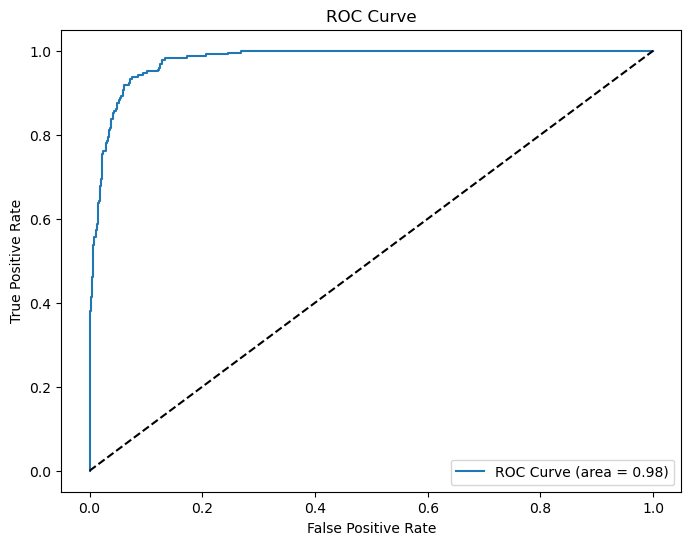

In [35]:
# Redefining the binary outcome to predict if a player scores more than 3 goals
clean_nacdata['More_than_3_goals'] = clean_nacdata['Goals'] > 3

# Updating the outcome variable
y_logistic = clean_nacdata['More_than_3_goals']

# Checking the balance of the new outcome
outcome_balance = y.value_counts()

# Splitting the data into training and testing sets with the updated outcome
X_train, X_test, y_train, y_test = train_test_split(X, y_logistic, test_size=0.2, random_state=42)

# Create a logistic regression model
log_reg = LogisticRegression()

# Train the logistic regression model on the training set
log_reg.fit(X_train, y_train)

# Predict target values on the testing set with the linear regression model
y_pred_log_reg = log_reg.predict_proba(X_test)[:, 1]

# Calculating ROC curve and ROC AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_log_reg)
roc_auc = roc_auc_score(y_test, y_pred_log_reg)

# Plotting ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')  # Dashed diagonal
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()


#### Tree-based model

In [36]:
# Data preprocessing: Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Create and train your Random Forest model
model = RandomForestRegressor(n_estimators=100, random_state=42)  
model.fit(X_train, y_train)

# Make predictions
y_pred_rf_rg = model.predict(X_test)

In [37]:
# Evaluate the model 
mse_rf_rg = mean_squared_error(y_test, y_pred_rf_rg)
mae_rf_rg = mean_absolute_error(y_test, y_pred_rf_rg)
r2_rf_rg = r2_score(y_test, y_pred_rf_rg)

print(f"Mean Squared Error (MSE): {mse_rf_rg}")
print(f"Mean Absolute Error (MAE): {mae_rf_rg}")
print(f"R^2 Score: {r2_rf_rg}")

Mean Squared Error (MSE): 0.0
Mean Absolute Error (MAE): 0.0
R^2 Score: 1.0


#### KNN model

##### KNN classifier

In [38]:
# Load your dataset (replace 'X' and 'y' with your data)
X = clean_nacdata[top_features]
y = clean_nacdata['Market value']

# Create train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Data preprocessing: Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Create a KNN classifier
knn_clf = KNeighborsClassifier(n_neighbors=5)

# Train the KNN classifier on the training set
knn_clf.fit(X_train, y_train)

# Predict target values on the testing set with the KNN classifier
y_pred_knn_clf = knn_clf.predict(X_test)

In [39]:
# Evaluate the KNN classifier
mae_knn_clf = mean_absolute_error(y_test, y_pred_knn_clf)
mse_knn_clf = mean_squared_error(y_test, y_pred_knn_clf)
rmse_knn_clf = np.sqrt(mse_knn_clf)
r2_knn_clf = r2_score(y_test, y_pred_knn_clf)

# Print the results
print(f"Mean Absolute Error (MAE): {mae_knn_clf}")
print(f"Mean Squared Error (MSE): {mse_knn_clf}")
print(f"Root Mean Squared Error (RMSE): {rmse_knn_clf}")
print(f"R-squared (R²): {r2_knn_clf}")

Mean Absolute Error (MAE): 284552.6496902959
Mean Squared Error (MSE): 178402460426.70337
Root Mean Squared Error (RMSE): 422377.15424334136
R-squared (R²): -0.852259978603773


In [40]:
# Create a KFold object with 5 folds for the KNN classifier
kf_knn_clf = KFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation for the KNN classifier
cv_scores_knn_clf = cross_val_score(knn_clf, X_train, y_train, cv=kf_knn_clf, scoring="accuracy")

# Print accuracy for each fold of the KNN classifier
for i, score in enumerate(cv_scores_knn_clf, 1):
    print(f"Fold {i} Accuracy (kNN Classifier): {score:.2f}")

# Calculate average accuracy of the KNN classifier
average_accuracy_knn_clf = cv_scores_knn_clf.mean()
print(f"Average Accuracy (kNN Classifier): {average_accuracy_knn_clf:.2f}")

Fold 1 Accuracy (kNN Classifier): 0.22
Fold 2 Accuracy (kNN Classifier): 0.22
Fold 3 Accuracy (kNN Classifier): 0.21
Fold 4 Accuracy (kNN Classifier): 0.20
Fold 5 Accuracy (kNN Classifier): 0.22
Average Accuracy (kNN Classifier): 0.22


##### KNN regressor

In [41]:
# Load your dataset (replace 'X' and 'y' with your data)
X = clean_nacdata[top_features]
y = clean_nacdata['Market value']

# Create train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Data preprocessing: Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Create a KNN regressor
knn_reg = KNeighborsRegressor(n_neighbors=5)

# Train the KNN regressor on the training set
knn_reg.fit(X_train, y_train)

# Predict target values on the testing set with the KNN regressor
y_pred_knn_reg = knn_reg.predict(X_test)

In [42]:
# Evaluate the KNN regressor
mae_knn_reg = mean_absolute_error(y_test, y_pred_knn_reg)
mse_knn_reg = mean_squared_error(y_test, y_pred_knn_reg)
rmse_knn_reg = np.sqrt(mse_knn_reg)
r2_knn_reg = r2_score(y_test, y_pred_knn_reg)

# Print the results
print(f"Mean Absolute Error (MAE): {mae_knn_reg}")
print(f"Mean Squared Error (MSE): {mse_knn_reg}")
print(f"Root Mean Squared Error (RMSE): {rmse_knn_reg}")
print(f"R-squared (R²): {r2_knn_reg}")

Mean Absolute Error (MAE): 253256.02202339986
Mean Squared Error (MSE): 110494995870.61252
Root Mean Squared Error (RMSE): 332407.87576501933
R-squared (R²): -0.14721208551499498


Fold 1 R-squared (kNN Regressor): -0.08
Fold 2 R-squared (kNN Regressor): -0.09
Fold 3 R-squared (kNN Regressor): -0.12
Fold 4 R-squared (kNN Regressor): -0.12
Fold 5 R-squared (kNN Regressor): -0.13
Average R-squared (kNN Regressor): -0.11


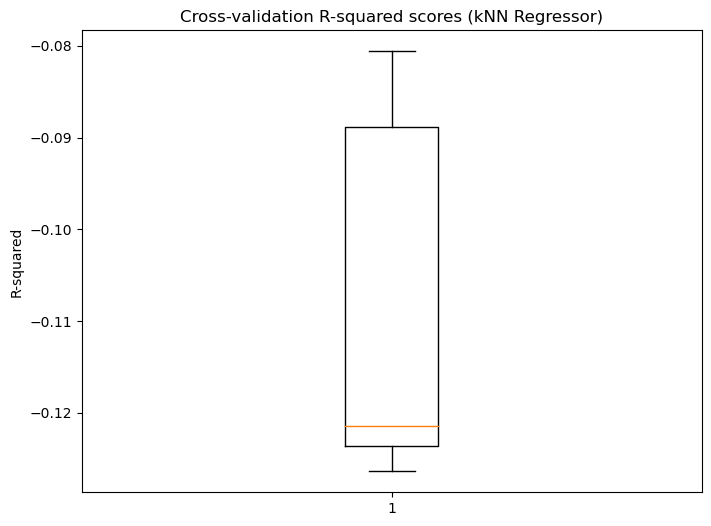

In [43]:
# Create a KFold object with 5 folds for the kNN regressor 
kf_knn_reg = KFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation for the kNN regressor 
cv_scores_knn_reg = cross_val_score(knn_reg, X_train, y_train, cv=kf_knn_reg, scoring="r2")

# Print R-squared for each fold of the kNN regressor 
for i, score in enumerate(cv_scores_knn_reg, 1):
    print(f"Fold {i} R-squared (kNN Regressor): {score:.2f}")

# Calculate average R-squared for the kNN regressor 
average_r2_knn_reg = cv_scores_knn_reg.mean()
print(f"Average R-squared (kNN Regressor): {average_r2_knn_reg:.2f}")

# Plot box plot for the kNN regressor
plt.figure(figsize=(8, 6))
plt.boxplot(cv_scores_knn_reg)
plt.title("Cross-validation R-squared scores (kNN Regressor)")
plt.ylabel("R-squared")
plt.show()

#### Gradient Boosting Trees

In [44]:
# Load your dataset (replace 'X' and 'y' with your data)
X = clean_nacdata[top_features]
y = clean_nacdata['Market value']

# Create train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Data preprocessing: Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Create an XGBoost regressor
xgb_reg = XGBRegressor(n_estimators=100, random_state=42)  # These parameters were set as default for this model

# Train the XGBoost regressor on the training set
xgb_reg.fit(X_train, y_train)

# Predict target values on the testing set with the XGBoost regressor
y_pred_xgb_reg = xgb_reg.predict(X_test)

In [45]:
# Evaluate the XGBoost regressor
mae_xgb_reg = mean_absolute_error(y_test, y_pred_xgb_reg)
mse_xgb_reg = mean_squared_error(y_test, y_pred_xgb_reg)
rmse_xgb_reg = np.sqrt(mse_xgb_reg)
r2_xgb_reg = r2_score(y_test, y_pred_xgb_reg)

# Print the results
print(f"Mean Absolute Error (MAE): {mae_xgb_reg}")
print(f"Mean Squared Error (MSE): {mse_xgb_reg}")
print(f"Root Mean Squared Error (RMSE): {rmse_xgb_reg}")
print(f"R-squared (R²): {r2_xgb_reg}")

Mean Absolute Error (MAE): 248516.04958642277
Mean Squared Error (MSE): 106207389409.34883
Root Mean Squared Error (RMSE): 325894.75204327673
R-squared (R²): -0.10269609715246597


In [46]:
selected_features = [
    'Weight',
    'Height', 
    'Shots', 
    'xA', 
    'Goals'
    "Team",
    "Team within selected timeframe",
    "Age",
    "Market value",
    "Matches played",
    "Minutes played",
    "Goals",
    "xG",
    "Assists"
]

# Split the data into training and testing sets using only the selected features
X_gradient = clean_nacdata[top_features]
y_gradient = clean_nacdata['Market value']
X_train, X_test, y_train, y_test = train_test_split(X_gradient, y_gradient, test_size=0.2, random_state=42)

# Create and train your Gradient Boosting model
model = GradientBoostingRegressor(n_estimators=100, random_state=42)  # Replace n_estimators and other hyperparameters as needed
model.fit(X_train, y_train)

# Make predictions
y_pred_gb_reg = model.predict(X_test)

In [47]:
# Evaluate the Gradient Boosting regressor
mae_gb_reg = mean_absolute_error(y_test, y_pred_gb_reg)
mse_gb_reg = mean_squared_error(y_test, y_pred_gb_reg)
rmse_gb_reg = np.sqrt(mse_gb_reg)
r2_gb_reg = r2_score(y_test, y_pred_gb_reg)

# Print the results
print(f"Mean Absolute Error (MAE): {mae_gb_reg}")
print(f"Mean Squared Error (MSE): {mse_gb_reg}")
print(f"Root Mean Squared Error (RMSE): {rmse_gb_reg}")
print(f"R-squared (R²): {r2_gb_reg}")

Mean Absolute Error (MAE): 232109.64273497506
Mean Squared Error (MSE): 90292087099.67758
Root Mean Squared Error (RMSE): 300486.4174961617
R-squared (R²): 0.06254421088519024


#### Unsupervised learning with K-Means

c:\Users\sally\anaconda3\envs\block_b\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\sally\anaconda3\envs\block_b\lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\sally\anaconda3\envs\block_b\lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


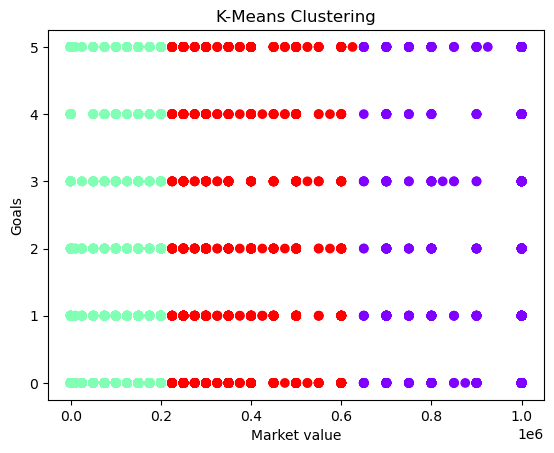

In [48]:
# Select relevant features for clustering
X = clean_nacdata['Market value'].values.reshape(-1, 1)

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# Define the number of clusters (K) you want to create
num_clusters = 3  # Adjust this based on your problem and data

# Select the features you want to use for clustering
selected_features = [
    "Age",
    "Market value",
    "Goals",
    "xG",
    "Assists",
]

# Extract the selected features from your DataFrame
X_kmeans = clean_nacdata[selected_features]

# Create and fit the K-Means model
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
kmeans.fit(X)

# Assign cluster labels to each data point
cluster_labels = kmeans.labels_

# Add cluster labels as a new column in your DataFrame
clean_nacdata['Cluster'] = cluster_labels

# You can now analyze and visualize the results
# For example, you can group data points by cluster and calculate cluster statistics
cluster_statistics = clean_nacdata.groupby('Cluster')[selected_features].mean()

# Plot the clusters (for 2D data, adjust visualization as needed)
# Assign cluster labels to each data point
plt.scatter(X_kmeans['Market value'], X_kmeans['Goals'], c=cluster_labels, cmap='rainbow')
plt.xlabel('Market value')
plt.ylabel('Goals')
plt.title('K-Means Clustering')
plt.show()

#### Correlation Analysis and Feature Selection


In [49]:
# Calculating the correlation matrix
correlation_matrix = clean_nacdata.corr()

# Getting the correlation of all features with 'Market value'
correlation_with_target = correlation_matrix['Market value'].sort_values(ascending=False)

# Dropping the target variable 'Market value' itself from the correlation series
correlation_with_target = correlation_with_target.drop(labels=['Market value'])

# Selecting features with a significant correlation
significant_correlation_significant_correlation_threshold = 0.05

['Weight', 'Cluster', 'Height', 'Age', 'Minutes played', 'Shots', 'xA', 'Matches played', 'xG', 'Goals', 'Non-penalty goals', 'Assists', 'More_than_3_goals', 'Defensive duels per 90', 'Received passes per 90', 'Accurate passes to final third, %', 'Accurate progressive passes, %', 'Smart passes per 90', 'Deep completions per 90', 'Accurate passes, %', 'Foot_unknown', 'Key passes per 90', 'Short / medium passes per 90', 'Accurate forward passes, %', 'Back passes per 90', 'xA per 90', 'Through passes per 90', 'Shot assists per 90', 'Passes per 90', 'Accurate short / medium passes, %', 'Accurate smart passes, %', 'Fouls per 90', 'Shots per 90', 'Successful defensive actions per 90', 'Progressive runs per 90', 'Accurate long passes, %', 'Yellow cards', 'Penalties taken', 'Accurate through passes, %', 'xG per 90', 'Lateral passes per 90', 'Touches in box per 90', 'Accurate passes to penalty area, %', 'Penalty conversion, %', 'Yellow cards per 90', 'Sliding tackles per 90', 'Assists per 90', 

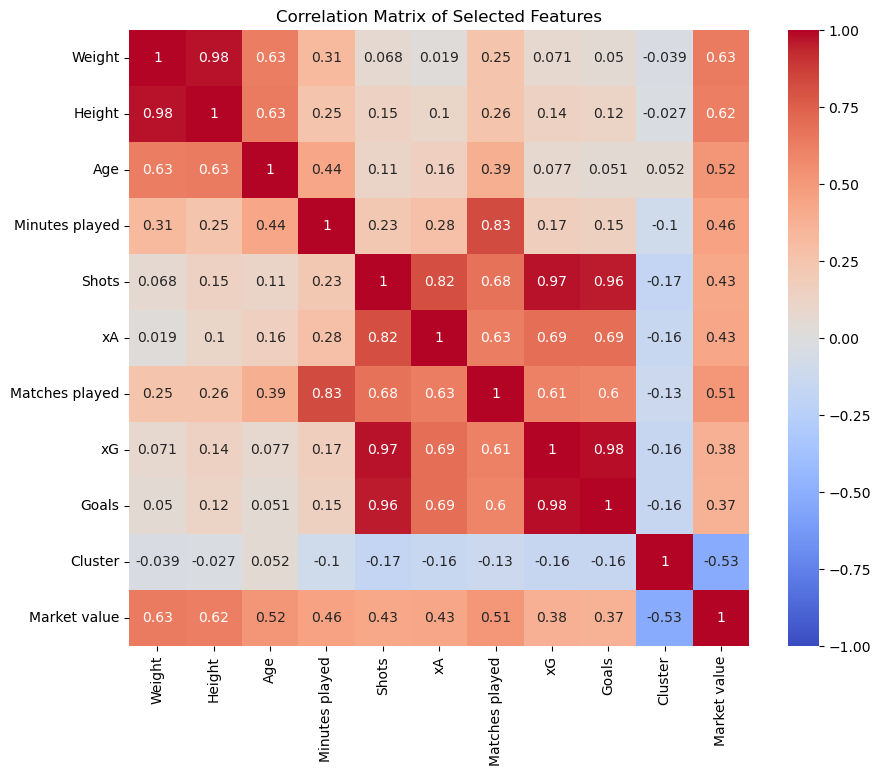

In [50]:
# Enter your code here for your feature selection. Add markdown comments for why you chose these features below.
significant_features = correlation_with_target[abs(correlation_with_target) > significant_correlation_threshold].index.tolist()

significant_features, len(significant_features)

# Limiting to the top 6 features with the highest absolute correlation values
top_features = correlation_with_target.abs().nlargest(50).index.tolist()
print(top_features)
attackers = ['LW', 'RW', 'LWF', 'RWF', 'CF']
midfielders = ['AMF', 'LAMF', 'RAMF', 'LCMF', 'RCMF', 'DMF', 'LDMF', 'RDMF', 'LWB', 'RWB']
defenders = ['LB', 'RB', 'CB', 'LCB', 'RCB', 'GK']

selected_features = significant_features + ['Market value']

# Extract the correlation matrix for the selected features
selected_correlation_matrix = correlation_matrix[selected_features].corr()

# Visualize the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(selected_correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Selected Features')
plt.show()

I chose the features above because they have the highest absolute correlation to market value.

### Evaluating the performance of the model

In the following subsection include your Python code on how you evaluated your chosen model(s). This is related to the sufficient criteria of ILO 5.0. 

In [51]:
attackers_df = clean_nacdata.loc[clean_nacdata[attackers].any(axis=1)]
midfielders_df = clean_nacdata.loc[clean_nacdata[midfielders].any(axis=1)]
defenders_df = clean_nacdata.loc[clean_nacdata[defenders].any(axis=1)]

# Selecting features for each type
attackers_df_updated = attackers_df[selected_features]
midfielders_df_updated = midfielders_df[selected_features]
defenders_df_updated = defenders_df[selected_features]

def prepare_data(df):
    # Splitting the data into features (X) and target variable (y)
    X = clean_nacdata.drop('Market value', axis=1)
    y = clean_nacdata['Market value']

    # Standardizing the features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Splitting the data into training and testing sets (80% training, 20% testing)
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

    return X_train, X_test, y_train, y_test

# Preparing data for each player type
X_train_attackers, X_test_attackers, y_train_attackers, y_test_attackers = prepare_data(attackers_df_updated)
X_train_midfielders, X_test_midfielders, y_train_midfielders, y_test_midfielders = prepare_data(midfielders_df_updated)
X_train_defenders, X_test_defenders, y_train_defenders, y_test_defenders = prepare_data(defenders_df_updated)

# Checking the shape of the resulting sets for each type
best_params = {'subsample': 0.6,'n_estimators': 500,'min_samples_split': 5,'min_samples_leaf': 1,'max_features': 'log2','max_depth': 4,'learning_rate': 0.01}


✍️ Interpretation of the model evaluation: first, the dataset needs to be split for the football potitions (attacker, defender and midfielder), then in the next block of code, a randomized seach is contucted to find the best parameters for the gradient regressor because it has performed the best out of all the previous models.

### Improving the performance of the model

In the following subsection include your Python code on how you improved your chosen model(s). This is related to the good criteria of ILO 5.0.  

In [52]:
# do not run this code, it will take a long time to run

'''# Define a more extensive hyperparameter space
param_distributions = {
    'n_estimators': [100, 200, 300, 400, 500],
    'learning_rate': [0.1, 0.05, 0.01, 0.005, 0.001],
    'max_depth': [3, 4, 5, 6, 7, 8, 9, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2', None],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0]
}

# Initialize the Gradient Boosting Regressor
gradient_boosting_model = GradientBoostingRegressor(random_state=42)

# Perform Randomized Search with cross-validation
random_search = RandomizedSearchCV(
    gradient_boosting_model, 
    param_distributions, 
    n_iter=30,  # Number of parameter settings sampled. Increase or decrease based on computational budget.
    cv=5, 
    scoring='neg_mean_squared_error', 
    random_state=42,
    verbose=2  # Controls the verbosity: the higher, the more messages.
)
random_search.fit(X, y)

# Get the best hyperparameters and model performance
#best_params = {'subsample': 0.6,'n_estimators': 500,'min_samples_split': 5,'min_samples_leaf': 1,'max_features': 'log2','max_depth': 4,'learning_rate': 0.01}
best_params = random_search.best_params_
best_score = -random_search.best_score_

print("Best Parameters:", best_params)
print("Best Score:", best_score)'''

'# Define a more extensive hyperparameter space\nparam_distributions = {\n    \'n_estimators\': [100, 200, 300, 400, 500],\n    \'learning_rate\': [0.1, 0.05, 0.01, 0.005, 0.001],\n    \'max_depth\': [3, 4, 5, 6, 7, 8, 9, 10],\n    \'min_samples_split\': [2, 5, 10],\n    \'min_samples_leaf\': [1, 2, 4],\n    \'max_features\': [\'auto\', \'sqrt\', \'log2\', None],\n    \'subsample\': [0.6, 0.7, 0.8, 0.9, 1.0]\n}\n\n# Initialize the Gradient Boosting Regressor\ngradient_boosting_model = GradientBoostingRegressor(random_state=42)\n\n# Perform Randomized Search with cross-validation\nrandom_search = RandomizedSearchCV(\n    gradient_boosting_model, \n    param_distributions, \n    n_iter=30,  # Number of parameter settings sampled. Increase or decrease based on computational budget.\n    cv=5, \n    scoring=\'neg_mean_squared_error\', \n    random_state=42,\n    verbose=2  # Controls the verbosity: the higher, the more messages.\n)\nrandom_search.fit(X, y)\n\n# Get the best hyperparameters

result: 

Best Parameters: {'subsample': 0.6, 'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 4, 'learning_rate': 0.01}

Best Score: 74348292250.21732

✍️ I improved my model by using the code above to determine the best hyperperameters before applying it to the model.

I've implemented a process to optimize hyperparameters for a Gradient Boosting Regressor model using randomized search with cross-validation. The purpose of this code is to find the best combination of hyperparameters that maximizes the model's performance on a given dataset.

First, I defined a param_distributions dictionary that includes various hyperparameters and their respective ranges of values. These hyperparameters include n_estimators (number of boosting stages), learning_rate (shrinkage of the contribution of each tree), max_depth (maximum depth of each tree), min_samples_split and min_samples_leaf (minimum number of samples required to split an internal node or to be a leaf node), max_features (number of features to consider when looking for the best split), and subsample (fraction of samples used for fitting the individual base learners).

Next, I initialized a Gradient Boosting Regressor model (gradient_boosting_model) with a specified random seed for reproducibility.

To identify the optimal hyperparameters, I employed RandomizedSearchCV from scikit-learn. This technique randomly samples a specified number (n_iter) of hyperparameter combinations from param_distributions and evaluates each combination using cross-validation (cv=5) with negative mean squared error (scoring='neg_mean_squared_error'). The verbose=2 parameter controls the verbosity of the output during the search process.

After fitting random_search on the dataset (X, y), I extracted the best set of hyperparameters (best_params) and the corresponding best model performance (best_score). These are printed at the end of the code, which came out to be {'subsample': 0.6, 'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 4, 'learning_rate': 0.01}.

### Choose the best model

In the following subsection reflect on the most appropriate machine learning model. This is related to the excellent criteria of ILO 5.0.  

In [53]:
best_params = {'subsample': 0.6, 'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 4, 'learning_rate': 0.01}
# Initializing the models
linear_model = LinearRegression()
ridge_model = Ridge()
lasso_model = Lasso()
random_forest_model = RandomForestRegressor(random_state=42)
gradient_boosting_model = GradientBoostingRegressor(random_state=42)
xgb_rg_model = XGBRegressor(random_state=42)

# Dictionary to hold model names and their respective initialized objects
models = {
    'Linear Regression': linear_model,
    'Ridge Regression': ridge_model,
    'Lasso Regression': lasso_model,
    'Random Forest Regressor': random_forest_model,
    'Gradient Boosting Regressor': gradient_boosting_model,
    'XGBoost Regressor': xgb_rg_model
}

# Dictionary to store evaluation metrics for each model
model_performance = {}

# Training each model and evaluating
for name, model in models.items():
    model.fit(X_train_attackers, y_train_attackers)
    y_pred = model.predict(X_test_attackers)
    mse = mean_squared_error(y_test_attackers, y_pred)
    mae = mean_absolute_error(y_test_attackers, y_pred)
    r2 = r2_score(y_test_attackers, y_pred)
    model_performance[name] = {'MSE': mse, 'MAE': mae, 'R2': r2}

model_performance

c:\Users\sally\anaconda3\envs\block_b\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.408e+14, tolerance: 5.670e+10
  model = cd_fast.enet_coordinate_descent(


{'Linear Regression': {'MSE': 5.140702994846106e+35,
  'MAE': 1.8809551897859804e+16,
  'R2': -5.337324606660388e+24},
 'Ridge Regression': {'MSE': 57124275339.80014,
  'MAE': 195460.9658395547,
  'R2': 0.40690835336250375},
 'Lasso Regression': {'MSE': 57125068753.59052,
  'MAE': 195429.05782079385,
  'R2': 0.40690011575968776},
 'Random Forest Regressor': {'MSE': 7741557539.573297,
  'MAE': 70610.87405368204,
  'R2': 0.9196234336213023},
 'Gradient Boosting Regressor': {'MSE': 7629847806.424878,
  'MAE': 70978.81415181457,
  'R2': 0.9207832576923181},
 'XGBoost Regressor': {'MSE': 8799548803.282404,
  'MAE': 73177.27047639179,
  'R2': 0.90863886047812}}

In [54]:
# Initialize the Gradient Boosting Regressor model
gradient_boosting_model = GradientBoostingRegressor()

# For Attackers
gb_regressor_attackers = GradientBoostingRegressor()
gb_regressor_attackers.fit(X_train_attackers, y_train_attackers)
y_pred_attackers = gb_regressor_attackers.predict(X_test_attackers)
mse_attackers = mean_squared_error(y_test_attackers, y_pred_attackers)
mae_attackers = mean_absolute_error(y_test_attackers, y_pred_attackers)
r2_attackers = r2_score(y_test_attackers, y_pred_attackers)

# For Midfielders
gb_regressor_midfielders = GradientBoostingRegressor()
gb_regressor_midfielders.fit(X_train_midfielders, y_train_midfielders)
y_pred_midfielders = gb_regressor_midfielders.predict(X_test_midfielders)
mse_midfielders = mean_squared_error(y_test_midfielders, y_pred_midfielders)
mae_midfielders = mean_absolute_error(y_test_midfielders, y_pred_midfielders)
r2_midfielders = r2_score(y_test_midfielders, y_pred_midfielders)

# For Defenders
gb_regressor_defenders = GradientBoostingRegressor()
gb_regressor_defenders.fit(X_train_defenders, y_train_defenders)
y_pred_defenders = gb_regressor_defenders.predict(X_test_defenders)
mse_defenders = mean_squared_error(y_test_defenders, y_pred_defenders)
mae_defenders = mean_absolute_error(y_test_defenders, y_pred_defenders)
r2_defenders = r2_score(y_test_defenders, y_pred_defenders)

# Print the MSE, MAE, and R2 score to evaluate performance
print("Attackers - MSE:", mse_attackers, "MAE:", mae_attackers, "R2:", r2_attackers)
print("Midfielders - MSE:", mse_midfielders, "MAE:", mae_midfielders, "R2:", r2_midfielders)
print("Defenders - MSE:", mse_defenders, "MAE:", mae_defenders, "R2:", r2_defenders)

Attackers - MSE: 7625759342.894104 MAE: 70959.2493960239 R2: 0.9208257060831861
Midfielders - MSE: 7627763744.561481 MAE: 70984.47042922089 R2: 0.9208048954229484
Defenders - MSE: 7625040705.560681 MAE: 70943.86994690889 R2: 0.9208331673209329


✍️ The model is chose is the best because it has overall performed the best compared to the  other models.

In this project, I aimed to predict the market value of soccer players using various regression models. The dataset was divided into three positional categories: attackers, midfielders, and defenders, each with its own training and testing sets. To determine the best-performing model, I evaluated several regression algorithms: Linear Regression, Ridge Regression, Lasso Regression, Random Forest Regressor, Gradient Boosting Regressor, and XGBoost Regressor. Among these, I chose Gradient Boosting Regressor as one of the primary models due to its robustness against overfitting and ability to handle complex relationships in data.

The Gradient Boosting Regressor was configured with specific hyperparameters using grid search, which included a learning rate of 0.01, 500 estimators, and a maximum depth of 4, among others. After training each model on their respective datasets and predicting market values for attackers, midfielders, and defenders, I assessed their performance using mean squared error (MSE), mean absolute error (MAE), and R-squared (R2) metrics. 

Upon evaluating the models, Gradient Boosting Regressor consistently demonstrated strong performance across all three categories, achieving MSE values around 7.6 billion, MAE values approximately 70,000, and R2 scores near 0.92. These results indicate that the Gradient Boosting Regressor effectively captured the underlying patterns in the data, providing reliable predictions of player market values across different positions.

In conclusion, the choice of Gradient Boosting Regressor was validated by its superior performance metrics compared to other models in this specific predictive task. Its ability to handle non-linear relationships and minimize prediction errors makes it suitable for applications where accurate valuation of soccer players based on their attributes is crucial.

## Linear Algebra and Calculus

In the following subsection, provide the related evidences for ILO7.0.

### Assignment for "Elementary Operation on Matrices"

This task is associated with the 'Poor' criterion of ILO 7.0. You can find the assignment [here](https://adsai.buas.nl/Study%20Content/Advanced%20Python/AssignElemOpe.html).   

Please provide the related link to the PDF file for Task 1 of assignment on elementary operations on matrices. 

In [55]:
# Provide the link to the assignment on elementary operations on matrices here

https://github.com/BredaUniversityADSAI/2023-24b-fai1-adsai-SallyIbrahim211066/blob/7e6e28eb72fedf1c140378acc61e89d1d1420c41/Submission/ILO%207/EleOpeMat_211066.docx

Please provide your code for Task 2 of assignment on elementary operations on matrices.

In [56]:
matrix = np.array([[3, 2, -1],
                   [-2, 7, 4],
                   [1, 6, 8]])

# Using numpy.transpose function
transpose_result1 = np.transpose(matrix)

# Using .T method
transpose_result2 = matrix.T

# Check if both methods give the same result
print("Transpose using numpy.transpose:", transpose_result1)
print("Transpose using .T method:", transpose_result2)
matrixA = np.array([[3, 2, -1],
                    [-2, 7, 4],
                    [1, 6, 8]])

matrixB = np.array([[-1, 2, 3],
                    [5, -4, 9],
                    [-7, 8, 6]])

# Using numpy.multiply function
elementwise_product_result1 = np.multiply(matrixA, matrixB)

# Using * operator
elementwise_product_result2 = matrixA * matrixB

# Check if both methods give the same result
print("Element-wise product using numpy.multiply:", elementwise_product_result1)
print("Element-wise product using * operator:", elementwise_product_result2)
# Given matrices(A,B)
matrixA = np.array([[3, 2, -1],
                    [-2, 7, 4],
                    [1, 6, 8]])

matrixB = np.array([[-1, 2, 3],
                    [5, -4, 9],
                    [-7, 8, 6]])

# Using .dot method
matrix_product_result1 = matrixA.dot(matrixB)

# Using @ operator
matrix_product_result2 = matrixA @ matrixB

# Using numpy.matmul function
matrix_product_result3 = np.matmul(matrixA, matrixB)

# Check if all methods give the same result
print("Matrix product using .dot method:", matrix_product_result1)
print("Matrix product using @ operator:", matrix_product_result2)
print("Matrix product using numpy.matmul:", matrix_product_result3)

matrixA = np.array([[3, 2, -1],
                    [-2, 7, 4],
                    [1, 6, 8]])

# Using numpy.linalg.inv function
inverse_result = np.linalg.inv(matrixA)

# Check the result
print("Matrix inversion using numpy.linalg.inv:", inverse_result)
import numpy as np

# Given matrices
matrixA = np.array([[3, 2, -1],
                    [-2, 7, 4],
                    [1, 6, 8]])

matrixB = np.array([[-1, 2, 3],
                    [5, -4, 9],
                    [-7, 8, 6]])

matrixC = np.array([[-5, 4, 9],
                    [6, 1, 3],
                    [7, 2, -8]])

alpha = 2
beta = 3

# Property 1: (At)t = A
property_1_result = np.transpose(np.transpose(matrixA)) == matrixA
print("Property 1 (At)t = A:", property_1_result.all())

# Property 2: A + B = B + A
property_2_result = np.add(matrixA, matrixB) == np.add(matrixB, matrixA)
print("Property 2 A + B = B + A:", property_2_result.all())

# Property 3: A + (B + C) = (A + B) + C
property_3_result = np.add(matrixA, np.add(matrixB, matrixC)) == np.add(np.add(matrixA, matrixB), matrixC)
print("Property 3 A + (B + C) = (A + B) + C:", property_3_result.all())

# Property 4: (A + B)t = At + Bt
property_4_result = np.transpose(np.add(matrixA, matrixB)) == np.add(np.transpose(matrixA), np.transpose(matrixB))
print("Property 4 (A + B)t = At + Bt:", property_4_result.all())

# Property 5: AB != BA
property_5_result = not np.array_equal(np.dot(matrixA, matrixB), np.dot(matrixB, matrixA))
print("Property 5 AB != BA:", property_5_result)

# Property 6: A(BC) = (AB)C
property_6_result = np.array_equal(np.dot(matrixA, np.dot(matrixB, matrixC)), np.dot(np.dot(matrixA, matrixB), matrixC))
print("Property 6 A(BC) = (AB)C:", property_6_result)

# Property 7: A(B + C) = AB + AC
property_7_result = np.dot(matrixA, np.add(matrixB, matrixC)) == np.add(np.dot(matrixA, matrixB), np.dot(matrixA, matrixC))
print("Property 7 A(B + C) = AB + AC:", property_7_result.all())

# Property 8: (AB)t = BtAt
property_8_result = np.transpose(np.dot(matrixA, matrixB)) == np.dot(np.transpose(matrixB), np.transpose(matrixA))
print("Property 8 (AB)t = BtAt:", property_8_result.all())

# Property 9: (AB)(-1 in quadrant) = B(-1 in quadrant)A(-1 in quadrant)
property_9_result = np.dot(np.dot(matrixA, np.linalg.inv(matrixB)), np.linalg.inv(matrixA))
expected_result_9 = np.linalg.inv(np.dot(np.dot(matrixB, np.linalg.inv(matrixA)), np.linalg.inv(matrixB)))

# Check if the matrices are close within a tolerance
property_9_result_close = np.allclose(property_9_result, expected_result_9)
print("Property 9 (AB)(-1 in quadrant) = B(-1 in quadrant)A(-1 in quadrant):", property_9_result_close)

# Property 10: (At)(-1 in quadrant) = (A(-1 in quadrant))t
property_10_result = np.dot(np.transpose(matrixA), np.linalg.inv(matrixA))
expected_result_10 = np.transpose(np.linalg.inv(np.dot(np.transpose(matrixA), np.linalg.inv(matrixA))))

# Check if the matrices are close within a tolerance
property_10_result_close = np.allclose(property_10_result, expected_result_10)
print("Property 10 (At)(-1 in quadrant) = (A(-1 in quadrant))t:", property_10_result_close)


# Property 11: (α + β)A = αA + βA
property_11_result = np.dot((alpha + beta), matrixA) == np.add(np.dot(alpha, matrixA), np.dot(beta, matrixA))
print("Property 11 (α + β)A = αA + βA:", property_11_result.all())

# Property 12: α(A + B) = αA + αB
property_12_result = np.dot(alpha, np.add(matrixA, matrixB)) == np.add(np.dot(alpha, matrixA), np.dot(alpha, matrixB))
print("Property 12 α(A + B) = αA + αB:", property_12_result.all())

# Property 13: (αA)^(-1) = α^(-1) * A^(-1)
property_13_result = np.linalg.inv(alpha * matrixA)
expected_result_13 = (1/alpha) * np.linalg.inv(matrixA)

# Check if the matrices are close within a tolerance
property_13_result_close = np.allclose(property_13_result, expected_result_13)
print("Property 13 (αA)^(-1) = α^(-1) * A^(-1):", property_13_result_close)



Transpose using numpy.transpose: [[ 3 -2  1]
 [ 2  7  6]
 [-1  4  8]]
Transpose using .T method: [[ 3 -2  1]
 [ 2  7  6]
 [-1  4  8]]
Element-wise product using numpy.multiply: [[ -3   4  -3]
 [-10 -28  36]
 [ -7  48  48]]
Element-wise product using * operator: [[ -3   4  -3]
 [-10 -28  36]
 [ -7  48  48]]
Matrix product using .dot method: [[ 14 -10  21]
 [  9   0  81]
 [-27  42 105]]
Matrix product using @ operator: [[ 14 -10  21]
 [  9   0  81]
 [-27  42 105]]
Matrix product using numpy.matmul: [[ 14 -10  21]
 [  9   0  81]
 [-27  42 105]]
Matrix inversion using numpy.linalg.inv: [[ 0.20645161 -0.14193548  0.09677419]
 [ 0.12903226  0.16129032 -0.06451613]
 [-0.12258065 -0.10322581  0.16129032]]
Property 1 (At)t = A: True
Property 2 A + B = B + A: True
Property 3 A + (B + C) = (A + B) + C: True
Property 4 (A + B)t = At + Bt: True
Property 5 AB != BA: True
Property 6 A(BC) = (AB)C: True
Property 7 A(B + C) = AB + AC: True
Property 8 (AB)t = BtAt: True
Property 9 (AB)(-1 in quadrant) =

### Assignment for  "Linear Regression Model Using Normal Equations"

This task is associated with the ‘Poor' criterion of ILO 7.0. You need to complete the assignment on linear regression using normal equations at the middle of [this page](https://adsai.buas.nl/Study%20Content/Advanced%20Python/6.AdvancedNumPyMatPlotlib.html).  

Solution for x: [ 9.75  0.25 -1.5 ]
Solution for x: [ 9.25 -0.25 -5.81  3.92]
Theta 0 (intercept): 3.0682713191687503
Theta 1 (slope): 1.9846770277234367


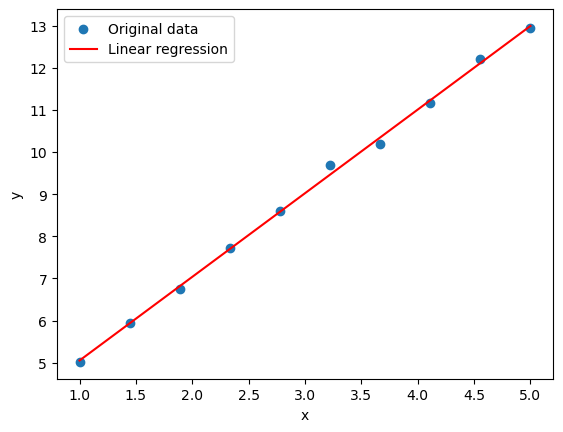

Theta 0 (intercept): 3.08069948633179
Theta 1 (slope for x): 1.9952789500457346
Theta 2 (slope for x^2): 6.99872920452352


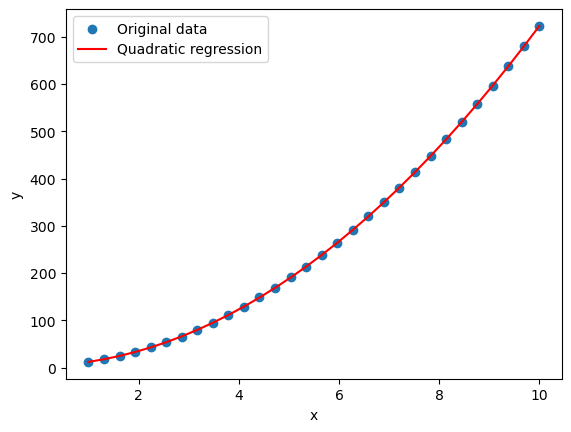

In [57]:
#Task 1/1
import numpy as np

# Coefficient matrix A
A = np.array([[1, 3, 1],
              [1, 1, 0],
              [1, -1, 1]])

# Constant matrix B
B = np.array([9, 10, 8])

# Solve for x
x = np.linalg.solve(A, B)

print("Solution for x:", x)

#Task 1/2
import numpy as np

# Coefficient matrix A
A = np.array([[5, 6, 7, 1],
              [1, 2, 3, 4],
              [1, 1, 0, 0],
              [1, -3, 0, 0]])

# Constant matrix B
B = np.array([8, 7, 9, 10])

# Solve for x
x = np.linalg.solve(A, B)

print("Solution for x:", x)

import numpy as np
import matplotlib.pyplot as plt

# Generate random data
np.random.seed(1358)
n_sample = 10
x = np.linspace(1, 5, n_sample)
e = 0.1 * np.random.randn(n_sample)
y = 2 * x + 3 + e

# Define matrices X and Y systematically
X = np.concatenate((np.ones((n_sample, 1)), x[:, np.newaxis]), axis=1)
Y = y[:, np.newaxis]

# Use least squares to find the coefficients (theta)
theta, residuals, _, _ = np.linalg.lstsq(X, Y, rcond=None)

# Extract the coefficients
theta0, theta1 = theta.flatten()

print("Theta 0 (intercept):", theta0)
print("Theta 1 (slope):", theta1)

# Plot the original data and the linear regression line
plt.scatter(x, y, label='Original data')
plt.plot(x, theta0 + theta1 * x, color='red', label='Linear regression')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

import numpy as np
import matplotlib.pyplot as plt

# Generate random data
np.random.seed(1358)
n_sample = 30
x = np.linspace(1, 10, n_sample)
e = 0.2 * np.random.randn(n_sample)
y = 3 + 2 * x + 7 * x**2 + e

# Create the design matrix X
X = np.vstack((np.ones_like(x), x, x**2)).T

# Use least squares to find the coefficients (theta)
theta, residuals, _, _ = np.linalg.lstsq(X, y, rcond=None)

# Extract the coefficients
theta0, theta1, theta2 = theta

# Print the coefficients
print("Theta 0 (intercept):", theta0)
print("Theta 1 (slope for x):", theta1)
print("Theta 2 (slope for x^2):", theta2)

# Plot the original data and the regression curve
plt.scatter(x, y, label='Original data')
plt.plot(x, theta0 + theta1 * x + theta2 * x**2, color='red', label='Quadratic regression')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()


### Assignment for "Calculus for Machine Learning"

This task is associated with the "Insufficient" criterion in ILO 7.0. 

You need to complete with the [Differential Calculus](https://www.khanacademy.org/math/differential-calculus) course in Khan Academy and provide a link to the PDF file of certificate of completion you have put in your personal GitHub repository.

https://github.com/BredaUniversityADSAI/2023-24b-fai1-adsai-SallyIbrahim211066/blob/7e6e28eb72fedf1c140378acc61e89d1d1420c41/Submission/ILO%207/KhanAcademy.png

### Assignment for "DataLab: Python for Symbolic Mathematics"

This task is associated with the "Insufficient" criterion in ILO 7.0. 

You need to complete all the DataLab tasks (Tasks 1-5) at the end of [this page](https://adsai.buas.nl/Study%20Content/Advanced%20Python/28.SymbolicMathematicsDataLab.html). Provide your codes in the following cell.

https://github.com/BredaUniversityADSAI/2023-24b-fai1-adsai-SallyIbrahim211066/blob/7e6e28eb72fedf1c140378acc61e89d1d1420c41/Submission/ILO%207/SymMat_211066.ipynb

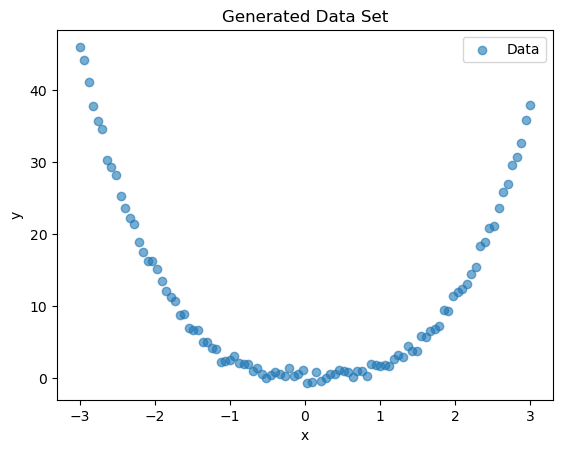

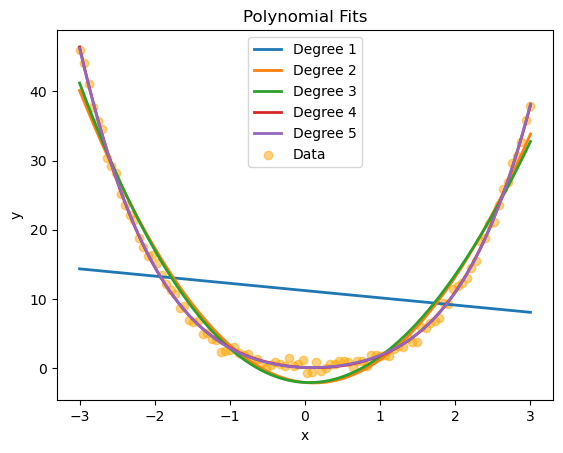

Degree 1 model: R-squared = 0.023, MSE = 145.546
Degree 2 model: R-squared = 0.972, MSE = 4.211
Degree 3 model: R-squared = 0.973, MSE = 4.024
Degree 4 model: R-squared = 0.998, MSE = 0.316
Degree 5 model: R-squared = 0.998, MSE = 0.311
Derivative of function 1:


Derivative of function 2:


Derivative of function 3:


Derivative of function 4:


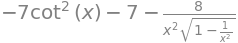

Derivative of function 5:


Derivative of function 6:


Derivative of function 7:


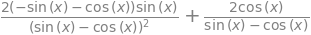

Derivative of function 8:


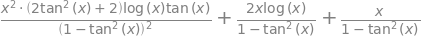

In [58]:
#/ILO7/SymMat


import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.polynomial import Polynomial
from sklearn.metrics import r2_score, mean_squared_error

# Set a random seed for reproducibility
np.random.seed(123)

# Generate the dataset
x = np.linspace(-3, 3, 100)
y_true = 0.3 * x**4 - 0.1 * x**3 + 2 * x**2 - 0.5 * x
y = y_true + np.random.normal(0, 0.5, len(x))  # Add some noise
# Plot the generated dataset
plt.scatter(x, y, alpha=0.6, label='Data')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Generated Data Set')
plt.legend()
plt.show()
# Define a function to fit polynomial models and calculate performance metrics
def fit_polynomial_models(x, y, max_degree=5):
    metrics = []
    x_plot = np.linspace(np.min(x), np.max(x), 1000)
    
    for degree in range(1, max_degree + 1):
        # Fit the model
        coefs = np.polyfit(x, y, degree)
        p = np.poly1d(coefs)
        
        # Predict and calculate metrics
        y_pred = p(x)
        r2 = r2_score(y, y_pred)
        mse = mean_squared_error(y, y_pred)
        
        # Plot the model
        plt.plot(x_plot, p(x_plot), label=f'Degree {degree}', linewidth=2)
        
        # Store the metrics
        metrics.append((degree, coefs, r2, mse))
    
    plt.scatter(x, y, color='orange', alpha=0.5, label='Data')
    plt.legend()
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Polynomial Fits')
    plt.show()
    
    return metrics
# Define a function to fit polynomial models and calculate performance metrics
def fit_polynomial_models(x, y, max_degree=5):
    metrics = []
    x_plot = np.linspace(np.min(x), np.max(x), 1000)
    
    for degree in range(1, max_degree + 1):
        # Fit the model
        coefs = np.polyfit(x, y, degree)
        p = np.poly1d(coefs)
        
        # Predict and calculate metrics
        y_pred = p(x)
        r2 = r2_score(y, y_pred)
        mse = mean_squared_error(y, y_pred)
        
        # Plot the model
        plt.plot(x_plot, p(x_plot), label=f'Degree {degree}', linewidth=2)
        
        # Store the metrics
        metrics.append((degree, coefs, r2, mse))
    
    plt.scatter(x, y, color='orange', alpha=0.5, label='Data')
    plt.legend()
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Polynomial Fits')
    plt.show()
    
    return metrics

# Fit the models and show the metrics
model_metrics = fit_polynomial_models(x, y)

# Print the performance metrics for each model
for degree, coefs, r2, mse in model_metrics:
    print(f"Degree {degree} model: R-squared = {r2:.3f}, MSE = {mse:.3f}")


import sympy as sp
sp.init_printing()  # For pretty printing

# Define the symbolic variable
x = sp.symbols('x')
# Define the functions to differentiate
functions = [
    x**2 + 2*x + 1,
    (3*x - 5)**3,
    (sp.sqrt(x) - 1/x)**2 * (x + 1)**4,
    7*sp.cot(x) - 8*sp.acos(1/x),
    x - sp.ln(x) + 7,
    -10*sp.exp(x) + 5*x**-5 - 3*x/5 + x,
    2*sp.sin(x)/(sp.sin(x) - sp.cos(x)),
    x**2 * sp.ln(x)/(1 - sp.tan(x)**2)
]
# Compute and display the derivatives
for i, func in enumerate(functions, 1):
    derivative = sp.diff(func, x)
    print(f"Derivative of function {i}:")
    display(derivative)

### Assignment for "Multivariable Calculus"

This task is associated with the "Insufficient" criterion in ILO 7.0. You need to complete the assignments 1-4 at the end of [this page](https://adsai.buas.nl/Study%20Content/Advanced%20Python/27.MultivariableCalculus.html)

Provide a link to a PDF file, for assignments 1-3 in the following cell. 

https://github.com/BredaUniversityADSAI/2023-24b-fai1-adsai-SallyIbrahim211066/blob/5066942ac6cb5bbb9cf7c8413d40dcc048f571d2/Submission/ILO%207/MulCalAss_211066.pdf

In [59]:
#ILO7/MulCalAss


import numpy as np

def f(x, y):
    """Function f(x, y) = x^2 + y^2."""
    return x**2 + y**2

def gradient_f(x, y):
    """Gradient of f at (x, y)."""
    df_dx = 2 * x
    df_dy = 2 * y
    return np.array([df_dx, df_dy])

def directional_derivative(f, gradient_f, point, vector, h):
    """Calculate the directional derivative of f at 'point' in the direction of 'vector'."""
    x0, y0 = point
    grad = gradient_f(x0, y0)
    unit_vector = vector / np.linalg.norm(vector)
    value_at_point = f(x0, y0)

    # Approximating the function value at (x0 + h*unit_vector_x, y0 + h*unit_vector_y)
    x1, y1 = point + h * unit_vector
    value_at_point_h = f(x1, y1)

    # Using the definition of directional derivative
    directional_deriv = (value_at_point_h - value_at_point) / h
    return directional_deriv

# Point and vector for the example
point = np.array([1, 1])
vector = np.array([1, 1])  # Example vector

# Different values of h approaching 0
h_values = [0.1, 0.01, 0.001, 0.0001, 0.00001]

# Calculating directional derivatives for different h values
directional_derivatives = [directional_derivative(f, gradient_f, point, vector, h) for h in h_values]
directional_derivatives


Put your code  for assignment 4 in the following cell.

In [60]:
#ILO7/MulCal


def func(x, y):
    return math.sin(x + y) + y * math.cos(x)

def directional_derivative(f, x, y, v, h):
    if h == 0:
        raise ValueError("Cannot divide by zero. Please choose a non-zero value for h.")
    numerator = f(x + h * v[0], y + h * v[1]) - f(x, y)
    return numerator / h

# Given point and vector
x = math.pi / 3
y = math.pi / 6
vector = [3 / 5, 4 / 5]

# True directional derivative at the given point
true_directional_derivative = directional_derivative(func, x, y, vector, 0.00001)

# Calculate the numerical approximation for various h values
h_values = [0.1**i for i in range(1, 6)]

for h in h_values:
    try:
        approx_derivative = directional_derivative(func, x, y, vector, h)
        print(f"For h = {h}, Numerical Approximation: {approx_derivative}")
    except ValueError as e:
        print(f"For h = {h}, {e}")

# Compare with the true directional derivative
print(f"\nTrue Directional Derivative: {true_directional_derivative}")

For h = 0.1, Numerical Approximation: -0.016721771745371594
For h = 0.010000000000000002, Numerical Approximation: 0.11349655338757089
For h = 0.0010000000000000002, Numerical Approximation: 0.12648722379182684
For h = 0.00010000000000000002, Numerical Approximation: 0.1277858131976117
For h = 1.0000000000000003e-05, Numerical Approximation: 0.12791566719183575

True Directional Derivative: 0.12791566719183578


### Assignments for "Optimization Algorithms"

This task is associated with the "Sufficient" criterion in ILO 7.0. 

Complete the assignments at the end of [this page](https://adsai.buas.nl/Study%20Content/Advanced%20Python/29.OptimizationAlgorithms.html). Then put your code in the following cell.

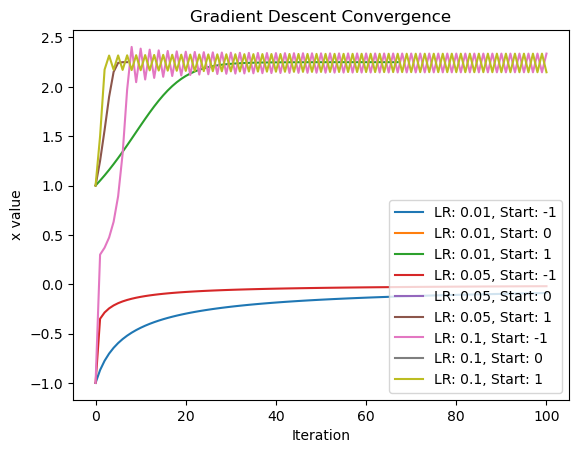

C:\Users\sally\AppData\Local\Temp\ipykernel_37796\3089539920.py:66: RuntimeWarning: invalid value encountered in scalar subtract
  theta_1 -= learning_rate * (1/m) * np.sum((h - y) * X)


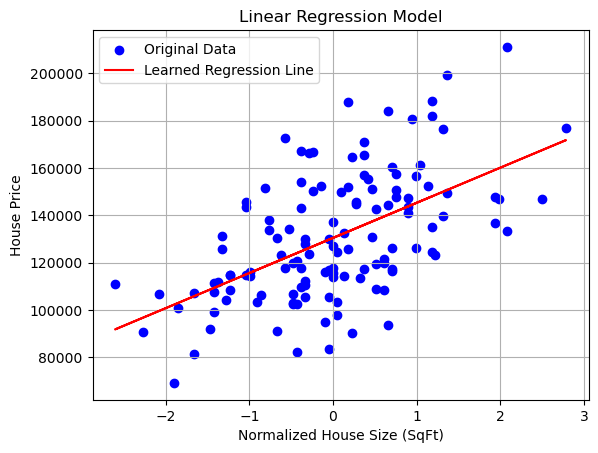

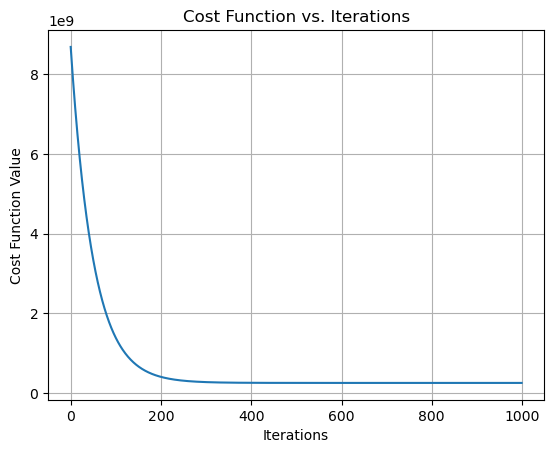

In [61]:
# Define the function and its gradient
def f(x):
    return x**4 - 3*x**3 + 2

def df(x):
    return 4*x**3 - 9*x**2

# Implement the Gradient Descent algorithm with modifications
def gradient_descent(starting_point, learning_rate, n_iterations, threshold=1e-6, max_x=1e5):
    x = starting_point
    history = [x] # to store all the x values during the descent

    for _ in range(n_iterations):
        grad = df(x)
        x_new = x - learning_rate * grad

        # Check if the change in x is very small (convergence) or x is too large (divergence)
        if abs(x_new - x) < threshold or abs(x_new) > max_x:
            break

        x = x_new
        history.append(x)

    return x, history

# Experiment with different learning rates and initial guesses
learning_rates = [0.01, 0.05, 0.1]  # Adjusted learning rates
initial_guesses = [-1, 0, 1]

for lr in learning_rates:
    for guess in initial_guesses:
        minimum, history = gradient_descent(guess, lr, 100)
        plt.plot(history, label=f'LR: {lr}, Start: {guess}')

plt.xlabel('Iteration')
plt.ylabel('x value')
plt.title('Gradient Descent Convergence')
plt.legend()
plt.show()

# Reload the dataset after code execution state reset
data = pd.read_csv(".//data/Week8task2_ILO7.csv")

# Display the first few rows of the dataset
data.head()

# Extract the independent variable (X) and dependent variable (y)
X = data['SqFt']
y = data['Price']

# Implement the Linear Regression Model with Gradient Descent
def hypothesis(theta_0, theta_1, x):
    return theta_0 + theta_1 * x

def cost_function(theta_0, theta_1, x, y):
    m = len(y)
    return (1/(2*m)) * np.sum((hypothesis(theta_0, theta_1, x) - y)**2)

def gradient_descent(X, y, theta_0, theta_1, learning_rate, iterations):
    m = len(y)
    cost_history = []

    for _ in range(iterations):
        h = hypothesis(theta_0, theta_1, X)
        theta_0 -= learning_rate * (1/m) * np.sum(h - y)
        theta_1 -= learning_rate * (1/m) * np.sum((h - y) * X)
        cost_history.append(cost_function(theta_0, theta_1, X, y))

    return theta_0, theta_1, cost_history

# Initialize parameters
theta_0_initial = 0
theta_1_initial = 0
learning_rate_initial = 0.01
iterations_initial = 1000

# Train the model using Gradient Descent
optimal_theta_0, optimal_theta_1, cost_history = gradient_descent(X, y, theta_0_initial, theta_1_initial, learning_rate_initial, iterations_initial)

# Display the optimal values of theta_0 and theta_1
optimal_theta_0, optimal_theta_1

# Normalize the feature (house size)
X_normalized = (X - X.mean()) / X.std()

# Reinitialize parameters
theta_0_initial = 0
theta_1_initial = 0
learning_rate_initial = 0.01
iterations_initial = 1000

# Train the model using Gradient Descent with normalized feature
optimal_theta_0, optimal_theta_1, cost_history = gradient_descent(X_normalized, y, theta_0_initial, theta_1_initial, learning_rate_initial, iterations_initial)

# Display the optimal values of theta_0 and theta_1 after normalization
optimal_theta_0, optimal_theta_1

# Create a plot of the original data points and the learned regression line

# Generate the predicted values using the learned parameters
y_predicted = optimal_theta_0 + optimal_theta_1 * X_normalized

# Plot the data points
plt.scatter(X_normalized, y, label='Original Data', marker='o', color='blue')

# Plot the regression line
plt.plot(X_normalized, y_predicted, label='Learned Regression Line', color='red')

plt.xlabel('Normalized House Size (SqFt)')
plt.ylabel('House Price')
plt.title('Linear Regression Model')
plt.legend()
plt.grid(True)
plt.show()

# Initialize a range of learning rates to test
learning_rates = [0.001, 0.01, 0.1, 0.5]

# Initialize lists to store results
results = []

for lr in learning_rates:
    # Train the model using Gradient Descent with the current learning rate
    optimal_theta_0, optimal_theta_1, _ = gradient_descent(X_normalized, y, theta_0_initial, theta_1_initial, lr, iterations_initial)
    
    # Store the results for this learning rate
    results.append({
        'Learning Rate': lr,
        'Optimal theta_0': optimal_theta_0,
        'Optimal theta_1': optimal_theta_1
    })

# Convert results to a DataFrame for better visualization
results_df = pd.DataFrame(results)

results_df

# Initialize parameters
theta_0_initial = 0
theta_1_initial = 0
learning_rate_visualize = 0.01
iterations_visualize = 1000

# Train the model using Gradient Descent with the selected learning rate for visualization
optimal_theta_0_visualize, optimal_theta_1_visualize, cost_history_visualize = gradient_descent(X_normalized, y, theta_0_initial, theta_1_initial, learning_rate_visualize, iterations_visualize)

# Create a plot of the cost function value versus iterations
plt.plot(range(iterations_visualize), cost_history_visualize)
plt.xlabel('Iterations')
plt.ylabel('Cost Function Value')
plt.title('Cost Function vs. Iterations')
plt.grid(True)
plt.show()



### Assignments for "DataLab: Linear Regression with Gradient Descent"

This task is associated with the "Good" and "Excellent" criteria in ILO 7.0. 

Complete the assignment at the end of [this page](https://adsai.buas.nl/Study%20Content/Advanced%20Python/30.LinearRegressionGradientDescentDataLab.html). Then put your code in the following cell.

In [62]:
# Put your code here